# Experiment Hub — Stock Fraud Screener

Personal research dashboard. Covers the full analytical stack in one place:

| Section | What it shows |
|---------|---------------|
| **1. Feature Selection** | IC / ICIR rankings, SHAP, selected features per horizon |
| **2. Model Performance** | OOF AUC, walk-forward AUC, regression IC, val/test split |
| **3. Screener Rankings** | All strategies ranked by Sharpe, CAGR, IC |
| **4. Screener Deep Dive** | Full profile for one screener (pick in Config) |
| **5. Live Picks** | Quality-gated long/short candidates for today |

---
**Workflow:** set Config → Run All → inspect each section.

## 0. Config — set everything here

In [1]:
from pathlib import Path

ROOT = Path("..")  # repo root relative to notebooks/

# ── Section 1 & 2: Feature / Model analysis ───────────────────────────────────
# Horizons to compare. Options: '6m' | '1y' | '2y' | '3y' | '5y'
HORIZONS = ['6m', '1y', '2y', '3y', '5y']

# How many top features to show in charts
TOP_FEATURES_N = 20

# ── Section 3: Screener rankings ─────────────────────────────────────────────
# Rank screeners by this metric. Options: 'sharpe' | 'cagr_pct' | 'excess_cagr_vs_spy' | 'calmar'
RANK_BY = 'sharpe'

# ── Section 4: Deep dive ──────────────────────────────────────────────────────
# 4a — Composite screener from screener_registry.json (7 named multi-factor configs)
# Options: 'COMPOSITE_US' | 'COMPOSITE_INTL' | 'COMPOSITE_MICRO' | 'VALUE_QUALITY'
#          'MOMENTUM_GROWTH' | 'FRAUD_AVOID' | 'WIDE_UNIVERSE'
SCREENER_REGISTRY_ID = 'COMPOSITE_US'

# 4b — Individual alpha signal from alpha_registry.json (8 single-factor signals)
# Options: 'alpha_value' | 'alpha_quality' | 'alpha_momentum' | 'alpha_growth'
#          'alpha_fraud_risk' | 'ml_1y_oof' | 'ml_3y_oof' | 'ml_5y_oof'
SCREENER_ID = 'ml_3y_oof'

# ── Section 5: Live picks ─────────────────────────────────────────────────────
USE_HF          = False           # True = pull from HuggingFace instead of local
HF_REPO         = 'ekrash718/stock-fraud-screener'
MARKETS         = None            # None = all; or ['US', 'KR', 'JP', 'BR', 'CA']
LIVE_HORIZON    = '3y'
TOP_N_LONG      = 25
TOP_N_SHORT     = 15
MIN_MARKET_CAP  = 10_000_000
MAX_MARKET_CAP  = 300_000_000
PIOTROSKI_MIN   = 5
BENEISH_MAX     = -1.78
ALTMAN_MIN      = 1.81
PB_MAX          = 3.0
FCF_YIELD_MIN   = 0.03
APPLY_MOS       = True
BETA_MAX        = 0.80
HALF_KELLY      = 0.25
MAX_LEVERAGE    = 2.0
POSITION_CAP    = 0.05
SECTOR_CAP      = 0.40

In [2]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 60)

# Paths
REPORTS = ROOT / 'reports'
MODELS  = ROOT / 'models'
DATA    = ROOT / 'data'

print('Paths OK:')
for p in [REPORTS, MODELS, DATA]:
    status = '✓' if p.exists() else '✗ MISSING'
    print(f'  {p}  {status}')

Paths OK:
  ../reports  ✓
  ../models  ✓
  ../data  ✓


---
## 1. Feature Selection Dashboard

In [3]:
# ── Load feature selection summary ───────────────────────────────────────────
fs_path = REPORTS / 'feature_selection_summary.csv'
fs = pd.read_csv(fs_path)
print(f"Feature selection summary: {fs.shape}  horizons: {fs['horizon'].unique()}")
fs.head(3)

Feature selection summary: (1077, 12)  horizons: ['6m' '1y' '2y' '3y' '5y']


,feature,mean_ic,std_ic,icir,n_years,pct_positive_ic,ic_tstat_nw,ic_pval_nw,fdr_reject,psi_train_vs_test,horizon,selected
0,ebitda,0.2292,0.0326,7.0297,2,1.0000,NaN,NaN,False,0.0367,6m,False
1,fcf_to_assets,0.1907,0.0500,3.8165,2,1.0000,NaN,NaN,False,0.0674,6m,False
2,quality_in_recession,0.1219,0.0498,2.4487,3,1.0000,243208.5898,0.0000,True,0.0000,6m,False


In [4]:
# ── Selected features per horizon (from feature_sets JSON) ───────────────────
selected_by_horizon = {}
for h in HORIZONS:
    p = MODELS / f'feature_sets_{h}.json'
    if p.exists():
        selected_by_horizon[h] = json.loads(p.read_text())
    else:
        selected_by_horizon[h] = []

print('Selected feature counts per horizon:')
for h, feats in selected_by_horizon.items():
    print(f'  {h}: {len(feats)} features')

Selected feature counts per horizon:
  6m: 4 features
  1y: 4 features
  2y: 4 features
  3y: 4 features
  5y: 4 features


In [5]:
# ── IC / ICIR table for the chosen HORIZONS ───────────────────────────────────
cols_to_show = ['feature', 'horizon', 'mean_ic', 'std_ic', 'icir', 'ic_tstat_nw',
                'fdr_reject', 'psi_train_vs_test', 'selected']
present = [c for c in cols_to_show if c in fs.columns]

ic_table = (
    fs[fs['horizon'].isin(HORIZONS)][present]
    .sort_values(['horizon', 'icir'], ascending=[True, False])
)

print(f'Features per horizon (IC > 0):')
for h in HORIZONS:
    sub = ic_table[ic_table['horizon'] == h]
    sel = sub['selected'].sum() if 'selected' in sub.columns else 'N/A'
    pos = (sub['mean_ic'] > 0).sum() if 'mean_ic' in sub.columns else 'N/A'
    print(f'  {h}: {len(sub)} total  |  {pos} positive IC  |  {sel} selected')

ic_table[ic_table['horizon'] == HORIZONS[-2]].head(20)  # show one horizon

Features per horizon (IC > 0):
  6m: 216 total  |  152 positive IC  |  36 selected
  1y: 216 total  |  145 positive IC  |  37 selected
  2y: 216 total  |  143 positive IC  |  36 selected
  3y: 216 total  |  139 positive IC  |  38 selected
  5y: 213 total  |  141 positive IC  |  35 selected


,feature,horizon,mean_ic,std_ic,icir,ic_tstat_nw,fdr_reject,psi_train_vs_test,selected
648,fcf_to_assets,3y,0.2476,0.0063,39.1531,NaN,False,0.0674,False
649,depreciation_amortization,3y,0.2432,0.0074,32.7566,NaN,False,0.0459,False
650,ebitda,3y,0.2942,0.0538,5.4726,NaN,False,0.0367,False
653,sales_to_price,3y,0.3155,0.0933,3.3820,10.4985,True,0.0796,False
654,debt_to_assets_sector_pct,3y,0.0779,0.0246,3.1667,9.6967,True,0.1492,True
655,value_x_momentum,3y,0.2329,0.0749,3.1088,12.3410,True,0.0387,True
656,quarterly_positive_rev_frac,3y,0.0828,0.0288,2.8742,10.8378,True,0.0000,True
662,value_composite,3y,0.2872,0.1146,2.5067,8.2205,True,0.1279,True
665,book_to_market,3y,0.2367,0.1024,2.3126,8.6564,True,0.1199,True
666,vol_rank_12m,3y,0.2424,0.1093,2.2172,8.0463,True,0.0015,True


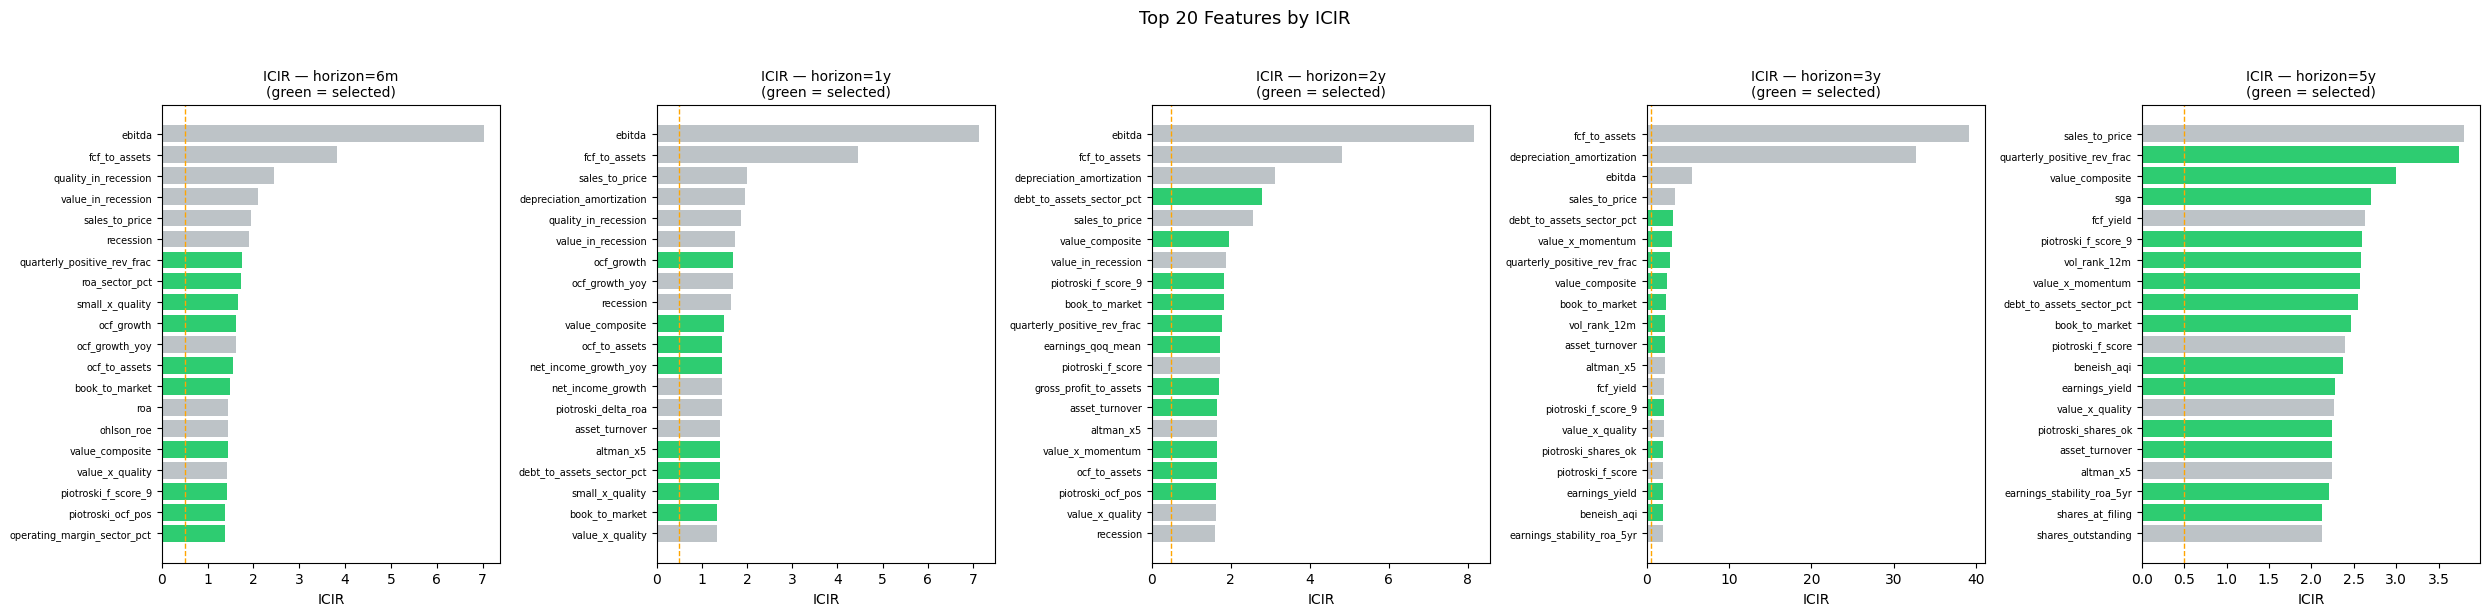

In [6]:
# ── ICIR bar chart: top N features for each horizon ──────────────────────────
n_horizons = len(HORIZONS)
fig, axes = plt.subplots(1, n_horizons, figsize=(5 * n_horizons, 6), sharey=False)
if n_horizons == 1:
    axes = [axes]

for ax, h in zip(axes, HORIZONS):
    sub = (
        fs[(fs['horizon'] == h) & fs['mean_ic'].notna()]
        .nlargest(TOP_FEATURES_N, 'icir')
        .sort_values('icir')
    )
    colors = ['#2ecc71' if s else '#bdc3c7' for s in sub.get('selected', [False]*len(sub))]
    ax.barh(sub['feature'], sub['icir'], color=colors, edgecolor='none')
    ax.axvline(0.5, color='orange', linestyle='--', linewidth=1, label='ICIR=0.5 threshold')
    ax.set_title(f'ICIR — horizon={h}\n(green = selected)', fontsize=10)
    ax.set_xlabel('ICIR')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle(f'Top {TOP_FEATURES_N} Features by ICIR', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

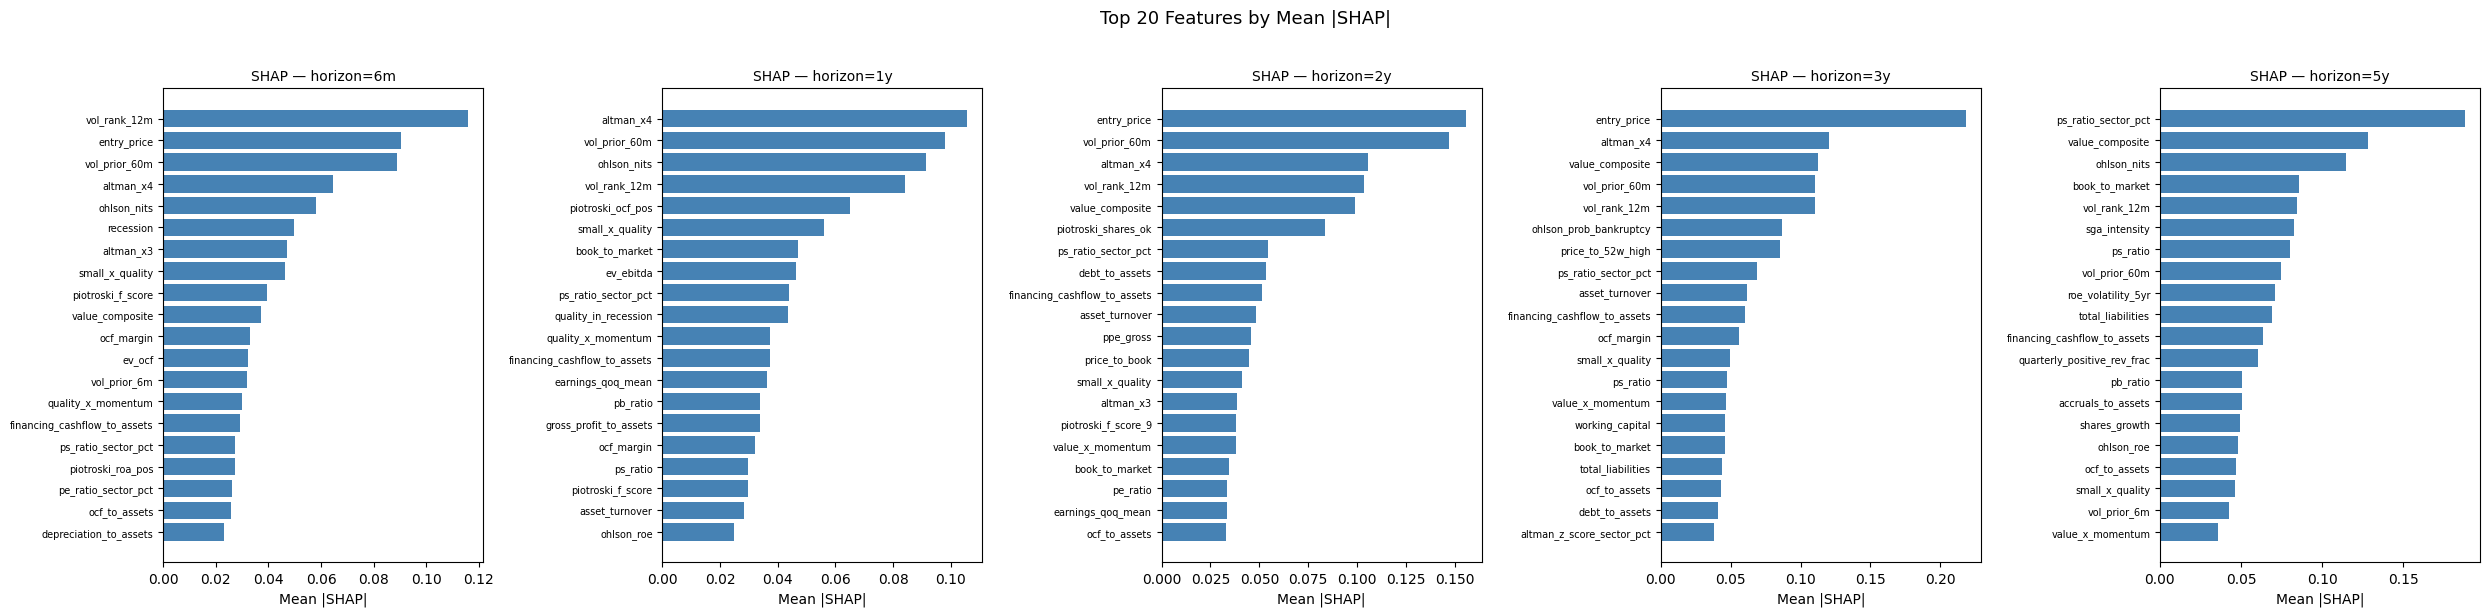

In [7]:
# ── SHAP importance per horizon ───────────────────────────────────────────────
shap_frames = {}
for h in HORIZONS:
    p = REPORTS / f'shap_importance_{h}.csv'
    if p.exists():
        shap_frames[h] = pd.read_csv(p).head(TOP_FEATURES_N)

fig, axes = plt.subplots(1, len(shap_frames), figsize=(5 * len(shap_frames), 6), sharey=False)
if len(shap_frames) == 1:
    axes = [axes]

for ax, (h, df_s) in zip(axes, shap_frames.items()):
    df_s = df_s.sort_values('shap_mean_abs')
    ax.barh(df_s['feature'], df_s['shap_mean_abs'], color='steelblue', edgecolor='none')
    ax.set_title(f'SHAP — horizon={h}', fontsize=10)
    ax.set_xlabel('Mean |SHAP|')
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle(f'Top {TOP_FEATURES_N} Features by Mean |SHAP|', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

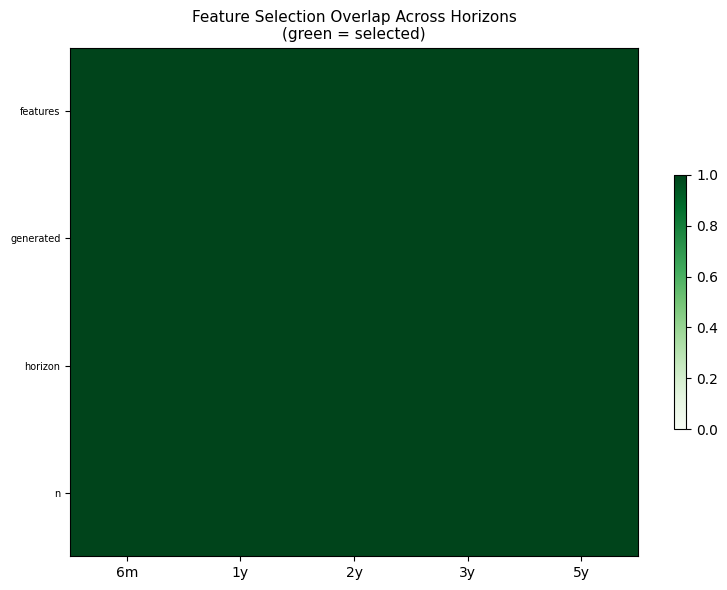


Features selected in ALL horizons: 4
Features selected in exactly 1 horizon: 0


In [8]:
# ── Feature overlap heatmap across horizons (selected features) ───────────────
all_selected = sorted(set(f for feats in selected_by_horizon.values() for f in feats))
overlap = pd.DataFrame(
    {h: [1 if f in selected_by_horizon[h] else 0 for f in all_selected]
     for h in HORIZONS},
    index=all_selected
)

if len(all_selected) > 0:
    # Sort by total appearances
    overlap['_total'] = overlap.sum(axis=1)
    overlap = overlap.sort_values('_total', ascending=False).drop(columns='_total')

    fig, ax = plt.subplots(figsize=(len(HORIZONS) * 1.2 + 2, max(6, len(overlap) * 0.35)))
    im = ax.imshow(overlap.values, cmap='Greens', aspect='auto', vmin=0, vmax=1)
    ax.set_xticks(range(len(HORIZONS)))
    ax.set_xticklabels(HORIZONS, fontsize=10)
    ax.set_yticks(range(len(all_selected)))
    ax.set_yticklabels(overlap.index, fontsize=7)
    ax.set_title('Feature Selection Overlap Across Horizons\n(green = selected)', fontsize=11)
    plt.colorbar(im, ax=ax, shrink=0.5)
    plt.tight_layout()
    plt.show()
    print(f'\nFeatures selected in ALL horizons: {(overlap.sum(axis=1) == len(HORIZONS)).sum()}')
    print(f'Features selected in exactly 1 horizon: {(overlap.sum(axis=1) == 1).sum()}')
else:
    print('No feature_sets JSON found.')

---
## 2. Model Performance Dashboard

In [9]:
# ── Load model_meta.json ─────────────────────────────────────────────────────
meta = json.loads((MODELS / 'model_meta.json').read_text())

perf_rows = []
for h in HORIZONS:
    m = meta.get(h, {})
    perf_rows.append({
        'horizon': h,
        'n_train': m.get('n_train'),
        'val_auc': m.get('val_auc'),
        'test_auc': m.get('test_auc'),
        'lr_val_auc': m.get('lr_val_auc'),
        'lr_test_auc': m.get('lr_test_auc'),
        'wf_mean_auc': m.get('wf_mean_auc'),
        'n_features': len(m.get('features', [])),
        'pos_rate': m.get('pos_rate'),
    })

perf_df = pd.DataFrame(perf_rows).set_index('horizon')
print('Model performance summary from model_meta.json:')
perf_df

Model performance summary from model_meta.json:


,n_train,val_auc,test_auc,lr_val_auc,lr_test_auc,wf_mean_auc,n_features,pos_rate
horizon,,,,,,,,
6m,32767,0.6059,0.5122,0.5947,0.5071,0.5653,28,0.4398
1y,32761,0.5970,0.4870,0.5932,0.5041,0.5726,23,0.4346
2y,32758,0.5787,0.5726,0.5679,0.5479,0.5801,24,0.4040
3y,32761,0.6469,NaN,0.5847,NaN,0.6158,26,0.3858
5y,24563,NaN,NaN,NaN,NaN,0.6084,21,0.3728


In [10]:
# ── OOF AUC folds per horizon ─────────────────────────────────────────────────
oof_frames = {}
for h in HORIZONS:
    p = REPORTS / f'oof_auc_{h}.csv'
    if p.exists():
        df_o = pd.read_csv(p)
        df_o['horizon'] = h
        oof_frames[h] = df_o

oof_all = pd.concat(oof_frames.values(), ignore_index=True) if oof_frames else pd.DataFrame()

if not oof_all.empty:
    print('OOF AUC by horizon (mean ± std):')
    print(oof_all.groupby('horizon')['auc'].agg(['mean', 'std', 'min', 'max']).round(4))

OOF AUC by horizon (mean ± std):
          mean    std    min    max
horizon                            
1y      0.5487 0.0387 0.4790 0.6027
2y      0.5778 0.0347 0.5184 0.6298
3y      0.6260 0.0282 0.5778 0.6596
5y      0.6573 0.0213 0.6270 0.6891
6m      0.5493 0.0344 0.4929 0.5904


In [11]:
# ── Walk-forward AUC per horizon ──────────────────────────────────────────────
wf_frames = {}
for h in HORIZONS:
    p = REPORTS / f'walk_forward_auc_{h}.csv'
    if p.exists():
        df_w = pd.read_csv(p)
        df_w['horizon'] = h
        wf_frames[h] = df_w

wf_all = pd.concat(wf_frames.values(), ignore_index=True) if wf_frames else pd.DataFrame()

if not wf_all.empty:
    print('Walk-forward AUC by horizon (mean ± std):')
    print(wf_all.groupby('horizon')['auc'].agg(['mean', 'std', 'min', 'max']).round(4))

Walk-forward AUC by horizon (mean ± std):
          mean    std    min    max
horizon                            
1y      0.5726 0.0334 0.4988 0.6017
2y      0.5801 0.0280 0.5255 0.6170
3y      0.6158 0.0330 0.5633 0.6631
5y      0.6084 0.0406 0.5198 0.6382
6m      0.5653 0.0356 0.4827 0.5985


In [12]:
# ── Regression IC per horizon ────────────────────────────────────────────────
reg_frames = {}
for h in HORIZONS:
    p = REPORTS / f'regression_ic_{h}.csv'
    if p.exists():
        df_r = pd.read_csv(p)
        df_r['horizon'] = h
        reg_frames[h] = df_r

reg_all = pd.concat(reg_frames.values(), ignore_index=True) if reg_frames else pd.DataFrame()

if not reg_all.empty:
    ic_col = [c for c in ['spearman_ic', 'ic', 'pearson_ic'] if c in reg_all.columns]
    if ic_col:
        ic_col = ic_col[0]
        print(f'Regression IC ({ic_col}) by horizon (mean ± std):')
        print(reg_all.groupby('horizon')[ic_col].agg(['mean', 'std', 'min', 'max']).round(4))

Regression IC (spearman_ic) by horizon (mean ± std):
          mean    std    min    max
horizon                            
1y      0.1580 0.0554 0.0818 0.2336
2y      0.2452 0.0647 0.1767 0.3486
3y      0.3362 0.0620 0.2735 0.4457
5y      0.4254 0.0466 0.3588 0.5027
6m      0.1273 0.0473 0.0461 0.1909


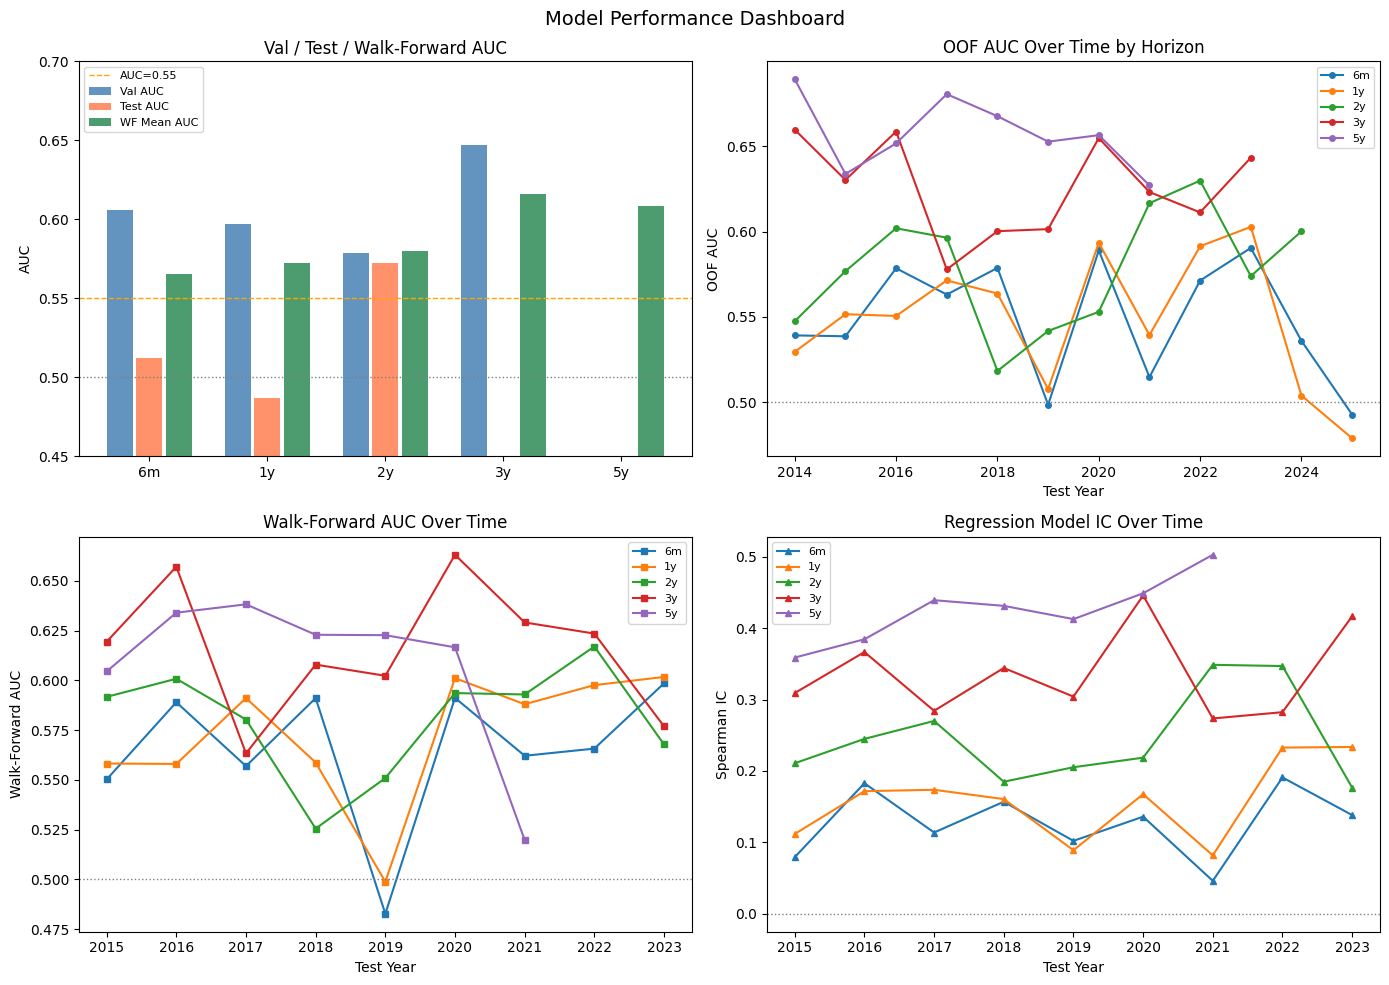

In [13]:
# ── Combined model performance chart ─────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. AUC comparison: val vs test vs walk-forward
ax = axes[0, 0]
x = range(len(HORIZONS))
ax.bar([i - 0.25 for i in x], perf_df['val_auc'],  width=0.22, label='Val AUC',  color='steelblue', alpha=0.85)
ax.bar([i + 0.00 for i in x], perf_df['test_auc'], width=0.22, label='Test AUC', color='coral',     alpha=0.85)
ax.bar([i + 0.25 for i in x], perf_df['wf_mean_auc'], width=0.22, label='WF Mean AUC', color='seagreen', alpha=0.85)
ax.axhline(0.55, color='orange', linestyle='--', linewidth=1, label='AUC=0.55')
ax.axhline(0.50, color='gray',   linestyle=':',  linewidth=1)
ax.set_xticks(list(x))
ax.set_xticklabels(HORIZONS)
ax.set_ylabel('AUC')
ax.set_title('Val / Test / Walk-Forward AUC')
ax.legend(fontsize=8)
ax.set_ylim(0.45, 0.70)

# 2. OOF AUC over time (walk-forward folds)
ax = axes[0, 1]
if not oof_all.empty and 'test_year' in oof_all.columns:
    for h in HORIZONS:
        sub = oof_all[oof_all['horizon'] == h].sort_values('test_year')
        ax.plot(sub['test_year'], sub['auc'], marker='o', markersize=4, label=h)
    ax.axhline(0.50, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Test Year')
    ax.set_ylabel('OOF AUC')
    ax.set_title('OOF AUC Over Time by Horizon')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'OOF AUC data unavailable', ha='center', va='center', transform=ax.transAxes)

# 3. Walk-forward AUC over time
ax = axes[1, 0]
if not wf_all.empty and 'test_year' in wf_all.columns:
    for h in HORIZONS:
        sub = wf_all[wf_all['horizon'] == h].sort_values('test_year')
        ax.plot(sub['test_year'], sub['auc'], marker='s', markersize=4, label=h)
    ax.axhline(0.50, color='gray', linestyle=':', linewidth=1)
    ax.set_xlabel('Test Year')
    ax.set_ylabel('Walk-Forward AUC')
    ax.set_title('Walk-Forward AUC Over Time')
    ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Walk-forward AUC data unavailable', ha='center', va='center', transform=ax.transAxes)

# 4. Regression IC over time
ax = axes[1, 1]
if not reg_all.empty and 'test_year' in reg_all.columns:
    ic_col_name = [c for c in ['spearman_ic', 'ic', 'pearson_ic'] if c in reg_all.columns]
    if ic_col_name:
        ic_col_name = ic_col_name[0]
        for h in HORIZONS:
            sub = reg_all[reg_all['horizon'] == h].sort_values('test_year')
            ax.plot(sub['test_year'], sub[ic_col_name], marker='^', markersize=4, label=h)
        ax.axhline(0.0, color='gray', linestyle=':', linewidth=1)
        ax.set_xlabel('Test Year')
        ax.set_ylabel('Spearman IC')
        ax.set_title('Regression Model IC Over Time')
        ax.legend(fontsize=8)
else:
    ax.text(0.5, 0.5, 'Regression IC data unavailable', ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Model Performance Dashboard', fontsize=14)
plt.tight_layout()
plt.show()

---
## 3. Screener Rankings — All Strategies

### 3a. Composite Screener Registry — 7 Named Strategies
> **Source:** `data/screener_registry.json` (built by `scripts/build_screener_registry.py`).  
> Each strategy runs a multi-factor composite filter through the full industry-grade backtester.

In [14]:
# ── Load screener registry ────────────────────────────────────────────────────
sreg_path = DATA / 'screener_registry.json'
if not sreg_path.exists():
    print(f"⚠ screener_registry.json not found at {sreg_path}")
    print("  Run: python3 scripts/build_screener_registry.py")
    sreg_raw = None
    screeners_df = pd.DataFrame()
else:
    sreg_raw = json.loads(sreg_path.read_text())
    rows = []
    for sid, v in sreg_raw.get('screeners', {}).items():
        if 'error' in v:
            continue
        cfg = v.get('config', {})
        rows.append({
            'id':                        sid,
            'name':                      cfg.get('name', sid),
            'description':               cfg.get('description', ''),
            'market':                    cfg.get('market', ''),
            'top_n':                     cfg.get('top_n'),
            'cost_bps':                  cfg.get('cost_bps'),
            'cagr_pct':                  v.get('cagr_pct'),
            'bench_cagr_pct':            v.get('bench_cagr_pct'),
            'excess_cagr_vs_spy':        v.get('excess_cagr_vs_spy'),
            'spy_cagr_pct':              v.get('spy_cagr_pct'),
            'sharpe':                    v.get('sharpe'),
            'sortino':                   v.get('sortino'),
            'calmar':                    v.get('calmar'),
            'max_drawdown_pct':          v.get('max_drawdown_pct'),
            'hit_rate_pct':              v.get('hit_rate_pct'),
            'n_years':                   v.get('n_years'),
            'beta_vs_spy':               v.get('beta_vs_spy'),
            'info_ratio':                v.get('info_ratio'),
            'best_year_pct':             v.get('best_year_pct'),
            'worst_year_pct':            v.get('worst_year_pct'),
            'cagr_bootstrap_mean_pct':   v.get('cagr_bootstrap_mean_pct'),
            'cagr_bootstrap_1sigma_pct': v.get('cagr_bootstrap_1sigma_pct'),
            'sharpe_bootstrap_mean':     v.get('sharpe_bootstrap_mean'),
            'sharpe_bootstrap_1sigma':   v.get('sharpe_bootstrap_1sigma'),
        })
    screeners_df = pd.DataFrame(rows)

    n_errors = sum(1 for v in sreg_raw['screeners'].values() if 'error' in v)
    print(f"Registry generated: {sreg_raw.get('generated_at', '?')}")
    print(f"Screeners loaded: {len(screeners_df)} | Errors: {n_errors}")

    leaderboard = screeners_df.sort_values(RANK_BY, ascending=False).reset_index(drop=True)
    leaderboard.index = range(1, len(leaderboard) + 1)
    lb_cols = ['id', 'name', 'cagr_pct', 'excess_cagr_vs_spy', 'sharpe', 'sortino',
               'calmar', 'max_drawdown_pct', 'hit_rate_pct', 'n_years']
    lb_present = [c for c in lb_cols if c in leaderboard.columns]
    print(f'\nLeaderboard (sorted by {RANK_BY}):')
    display(leaderboard[lb_present])

Registry generated: 2026-05-14T22:29:45.200473
Screeners loaded: 7 | Errors: 0

Leaderboard (sorted by sharpe):


,id,name,cagr_pct,excess_cagr_vs_spy,sharpe,sortino,calmar,max_drawdown_pct,hit_rate_pct,n_years
1,COMPOSITE_INTL,Composite — International,29.5300,27.9200,2.1940,2.1940,1.2210,0.0000,75.0000,2
2,WIDE_UNIVERSE,Wide Universe,22.2600,9.2400,1.4000,1.4000,1.2400,-17.9500,72.1000,14
3,COMPOSITE_MICRO,Composite — Micro/Small Cap,18.6700,5.6500,1.0320,34.6180,0.7540,-24.7800,63.3000,14
4,COMPOSITE_US,Composite — US All-Cap,20.9800,7.9600,0.9830,0.9830,1.0850,-19.3300,68.9000,14
5,FRAUD_AVOID,Fraud-Screened Composite,21.5100,8.4900,0.9110,13.8040,0.7600,-28.3000,70.0000,14
6,MOMENTUM_GROWTH,Momentum + Growth,15.2200,2.2000,0.8480,5.7330,0.7900,-19.2800,62.5000,14
7,VALUE_QUALITY,Value + Quality,12.4900,-0.5300,0.5620,1.7940,0.3900,-32.0400,62.0000,14


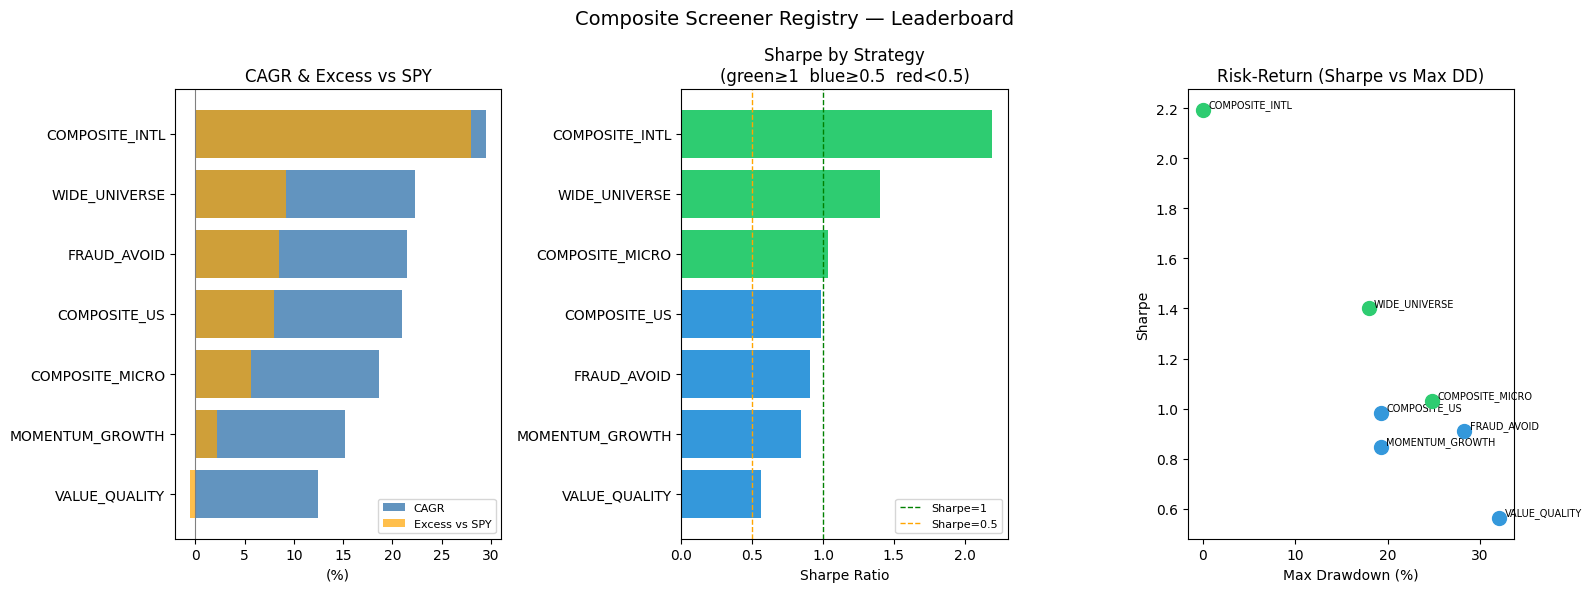

In [15]:
# ── Composite screener rankings chart ────────────────────────────────────────
if not screeners_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))

    # CAGR + excess vs SPY
    ax = axes[0]
    s = screeners_df.sort_values('cagr_pct', ascending=True)
    ax.barh(s['id'], s['cagr_pct'], color='steelblue', alpha=0.85, label='CAGR')
    if 'excess_cagr_vs_spy' in s.columns:
        ax.barh(s['id'], s['excess_cagr_vs_spy'], color='orange', alpha=0.7, label='Excess vs SPY')
    ax.axvline(0, color='gray', linewidth=0.8)
    ax.set_xlabel('(%)')
    ax.set_title('CAGR & Excess vs SPY')
    ax.legend(fontsize=8)

    # Sharpe
    ax = axes[1]
    s2 = screeners_df.sort_values('sharpe', ascending=True)
    colors_sharpe = ['#2ecc71' if v >= 1.0 else ('#3498db' if v >= 0.5 else '#e74c3c')
                     for v in s2['sharpe'].fillna(0)]
    ax.barh(s2['id'], s2['sharpe'], color=colors_sharpe, edgecolor='none')
    ax.axvline(1.0, color='green',  linestyle='--', linewidth=1, label='Sharpe=1')
    ax.axvline(0.5, color='orange', linestyle='--', linewidth=1, label='Sharpe=0.5')
    ax.set_xlabel('Sharpe Ratio')
    ax.set_title('Sharpe by Strategy\n(green≥1  blue≥0.5  red<0.5)')
    ax.legend(fontsize=8)

    # Sharpe vs Max Drawdown scatter
    ax = axes[2]
    for _, row in screeners_df.iterrows():
        v = row.get('sharpe', 0) or 0
        c = '#2ecc71' if v >= 1.0 else ('#3498db' if v >= 0.5 else '#e74c3c')
        ax.scatter(abs(row.get('max_drawdown_pct', 0) or 0), row.get('sharpe', 0),
                   color=c, s=100, zorder=3)
        ax.annotate(row['id'], (abs(row.get('max_drawdown_pct', 0) or 0), row.get('sharpe', 0)),
                    fontsize=7, xytext=(4, 2), textcoords='offset points')
    ax.set_xlabel('Max Drawdown (%)')
    ax.set_ylabel('Sharpe')
    ax.set_title('Risk-Return (Sharpe vs Max DD)')

    plt.suptitle('Composite Screener Registry — Leaderboard', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No screener_registry.json data to chart.")

### 3b. Individual Alpha Signal Rankings
> **Source:** `data/alpha_registry.json` (8 individual alpha signals: 5 factor scores + 3 ML OOF).  
> The cells below show rankings and charts for all individual signals.

In [16]:
# ── Load alpha registry ───────────────────────────────────────────────────────
registry = json.loads((DATA / 'alpha_registry.json').read_text())
signals = pd.DataFrame(registry['signals'])
print(f"Registry generated: {registry.get('generated_at','?')}")
print(f"Total signals: {len(signals)}  |  Selected: {signals['selected'].sum()}")
signals.head(3)

Registry generated: 2026-05-14T01:21:20.222153
Total signals: 8  |  Selected: 6


,signal_id,category,horizon,market,features_used,ic_mean,icir,cagr_pct,cagr_bootstrap_mean_pct,cagr_bootstrap_1sigma_pct,sharpe,sharpe_bootstrap_mean,sharpe_bootstrap_1sigma,sortino,calmar,max_drawdown_pct,max_drawdown_note,excess_cagr_vs_spy,beta_vs_spy,hit_rate_pct,n_years,top_n,cost_bps,selected
0,alpha_value,factor,1y,all,"[ev_ebitda, ev_revenue, fcf_yield, earnings_yi...",0.1521,1.5748,27.0000,27.9800,5.4100,0.7760,0.9170,0.2610,13.3310,5.4380,-4.9600,None,13.1300,0.9860,75.7000,15,20,30,True
1,alpha_quality,factor,1y,all,"[roe, roa, roic, gross_margin, operating_margi...",0.0944,0.9492,11.6400,11.3500,3.4600,0.5100,0.5420,0.2690,1.7980,0.6260,-18.5800,None,-2.2300,0.5120,61.7000,15,20,30,True
2,alpha_momentum,factor,1y,all,"[momentum_12m_prior, momentum_6m_prior, moment...",0.0380,0.3163,-1.2700,0.5800,8.5100,-0.1050,-0.0710,0.2420,-0.2100,-0.0160,-80.6000,None,-15.1300,0.3060,39.7000,15,20,30,False


In [17]:
# ── Full rankings table ───────────────────────────────────────────────────────
rank_cols = [
    'signal_id', 'category', 'selected',
    'ic_mean', 'icir',
    'cagr_pct', 'cagr_bootstrap_mean_pct', 'cagr_bootstrap_1sigma_pct',
    'sharpe', 'sharpe_bootstrap_mean',
    'sortino', 'calmar',
    'max_drawdown_pct', 'excess_cagr_vs_spy',
    'beta_vs_spy', 'hit_rate_pct', 'n_years', 'top_n', 'cost_bps'
]
present_rank = [c for c in rank_cols if c in signals.columns]
rankings = signals[present_rank].sort_values(RANK_BY, ascending=False).reset_index(drop=True)
rankings.index = range(1, len(rankings) + 1)

print(f'All screeners ranked by {RANK_BY} (descending):')
rankings

All screeners ranked by sharpe (descending):


,signal_id,category,selected,ic_mean,icir,cagr_pct,cagr_bootstrap_mean_pct,cagr_bootstrap_1sigma_pct,sharpe,sharpe_bootstrap_mean,sortino,calmar,max_drawdown_pct,excess_cagr_vs_spy,beta_vs_spy,hit_rate_pct,n_years,top_n,cost_bps
1,ml_5y_oof,ml,True,0.3901,7.1876,38.3400,38.0400,6.6300,1.2370,1.6520,1.2370,0.6710,0.0000,26.4200,-0.7090,73.5000,10,20,30
2,alpha_fraud_risk,factor,True,0.1989,1.6057,31.0000,31.6300,3.9800,1.2110,1.3150,1.2110,0.6700,0.0000,17.1400,0.5510,77.3000,15,20,30
3,ml_3y_oof,ml,True,0.3352,5.2221,32.1500,30.3300,5.7900,1.1670,1.5090,1.1670,0.6440,0.0000,20.2300,0.5160,77.0000,10,20,30
4,ml_1y_oof,ml,True,0.1534,1.7933,20.9500,21.9300,4.9000,0.8430,1.0970,5.6760,4.9730,-4.2100,9.0300,0.3900,68.0000,10,20,30
5,alpha_value,factor,True,0.1521,1.5748,27.0000,27.9800,5.4100,0.7760,0.9170,13.3310,5.4380,-4.9600,13.1300,0.9860,75.7000,15,20,30
6,alpha_quality,factor,True,0.0944,0.9492,11.6400,11.3500,3.4600,0.5100,0.5420,1.7980,0.6260,-18.5800,-2.2300,0.5120,61.7000,15,20,30
7,alpha_growth,factor,False,0.0459,1.1536,6.5300,7.3400,4.2400,0.2060,0.3210,0.3730,0.2020,-32.3500,-6.4900,0.1890,52.1000,14,20,30
8,alpha_momentum,factor,False,0.0380,0.3163,-1.2700,0.5800,8.5100,-0.1050,-0.0710,-0.2100,-0.0160,-80.6000,-15.1300,0.3060,39.7000,15,20,30


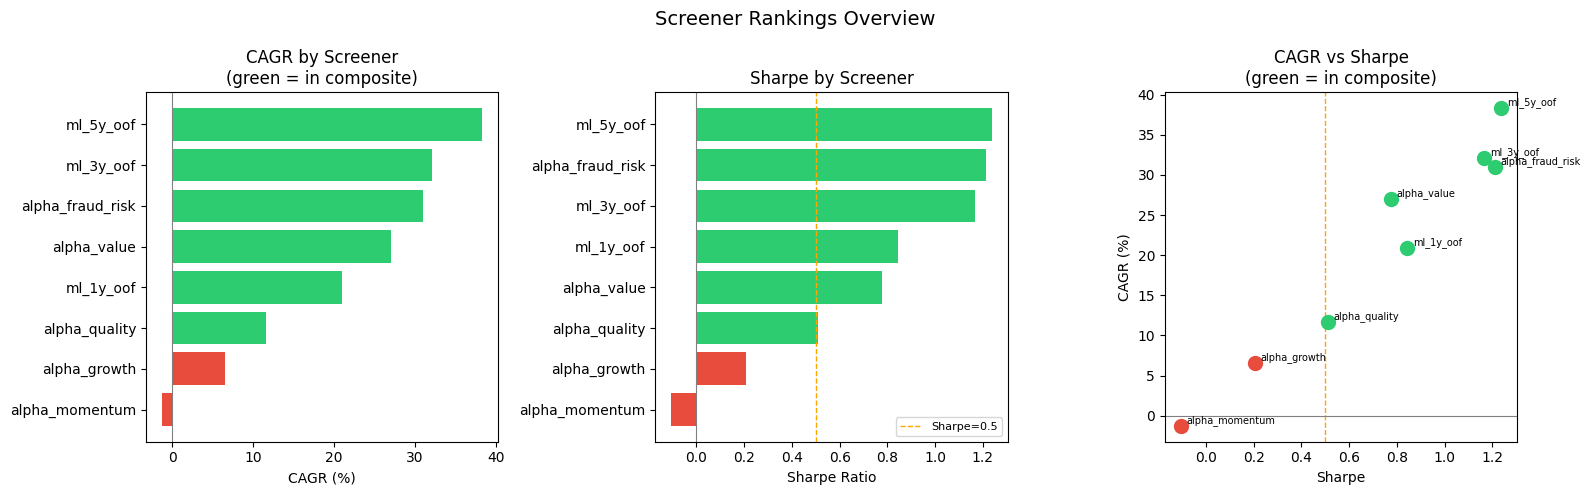

In [18]:
# ── Screener rankings chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

palette = ['#2ecc71' if s else '#e74c3c' for s in signals['selected']]

# CAGR bar
ax = axes[0]
sorted_s = signals.sort_values('cagr_pct', ascending=True)
colors = ['#2ecc71' if s else '#e74c3c' for s in sorted_s['selected']]
ax.barh(sorted_s['signal_id'], sorted_s['cagr_pct'], color=colors, edgecolor='none')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('CAGR (%)')
ax.set_title('CAGR by Screener\n(green = in composite)')

# Sharpe bar
ax = axes[1]
sorted_s2 = signals.sort_values('sharpe', ascending=True)
colors2 = ['#2ecc71' if s else '#e74c3c' for s in sorted_s2['selected']]
ax.barh(sorted_s2['signal_id'], sorted_s2['sharpe'], color=colors2, edgecolor='none')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=1, label='Sharpe=0.5')
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Sharpe Ratio')
ax.set_title('Sharpe by Screener')
ax.legend(fontsize=8)

# CAGR vs Sharpe scatter
ax = axes[2]
for _, row in signals.iterrows():
    c = '#2ecc71' if row.get('selected') else '#e74c3c'
    ax.scatter(row.get('sharpe', np.nan), row.get('cagr_pct', np.nan),
               color=c, s=100, zorder=3)
    ax.annotate(row['signal_id'], (row.get('sharpe', 0), row.get('cagr_pct', 0)),
                fontsize=7, xytext=(4, 2), textcoords='offset points')
ax.axvline(0.5, color='orange', linestyle='--', linewidth=1)
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Sharpe')
ax.set_ylabel('CAGR (%)')
ax.set_title('CAGR vs Sharpe\n(green = in composite)')

plt.suptitle('Screener Rankings Overview', fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# ── Risk-adjusted metrics summary ─────────────────────────────────────────────
risk_cols = ['signal_id', 'sharpe', 'sortino', 'calmar', 'max_drawdown_pct',
             'excess_cagr_vs_spy', 'beta_vs_spy', 'hit_rate_pct']
risk_present = [c for c in risk_cols if c in signals.columns]
risk_table = signals[risk_present].sort_values('sharpe', ascending=False).reset_index(drop=True)
risk_table.index = range(1, len(risk_table) + 1)
print('Risk-adjusted metrics (sorted by Sharpe):')
risk_table

Risk-adjusted metrics (sorted by Sharpe):


,signal_id,sharpe,sortino,calmar,max_drawdown_pct,excess_cagr_vs_spy,beta_vs_spy,hit_rate_pct
1,ml_5y_oof,1.2370,1.2370,0.6710,0.0000,26.4200,-0.7090,73.5000
2,alpha_fraud_risk,1.2110,1.2110,0.6700,0.0000,17.1400,0.5510,77.3000
3,ml_3y_oof,1.1670,1.1670,0.6440,0.0000,20.2300,0.5160,77.0000
4,ml_1y_oof,0.8430,5.6760,4.9730,-4.2100,9.0300,0.3900,68.0000
5,alpha_value,0.7760,13.3310,5.4380,-4.9600,13.1300,0.9860,75.7000
6,alpha_quality,0.5100,1.7980,0.6260,-18.5800,-2.2300,0.5120,61.7000
7,alpha_growth,0.2060,0.3730,0.2020,-32.3500,-6.4900,0.1890,52.1000
8,alpha_momentum,-0.1050,-0.2100,-0.0160,-80.6000,-15.1300,0.3060,39.7000


---
## 4. Screener Deep Dive

> **4a** — composite strategy from `screener_registry.json` → set `SCREENER_REGISTRY_ID` in Config.  
> **4b** — individual alpha signal from `alpha_registry.json` → set `SCREENER_ID` in Config.

### 4a. Composite Screener Deep Dive — `SCREENER_REGISTRY_ID`
> Full performance profile for the selected composite screener from `screener_registry.json`.  
> **Change `SCREENER_REGISTRY_ID` in Config** to switch strategies.

In [20]:
# ── Load composite screener stats from registry ───────────────────────────────
if sreg_raw is None:
    print("⚠ screener_registry.json not loaded. Run build_screener_registry.py first.")
elif SCREENER_REGISTRY_ID not in sreg_raw.get('screeners', {}):
    print(f"⚠ '{SCREENER_REGISTRY_ID}' not found in registry.")
    print(f"Available: {list(sreg_raw['screeners'].keys())}")
else:
    s4a = sreg_raw['screeners'][SCREENER_REGISTRY_ID]
    cfg4a = s4a.get('config', {})
    print(f"{'═'*60}")
    print(f"  SCREENER: {SCREENER_REGISTRY_ID}  —  {cfg4a.get('name', '')}")
    print(f"{'═'*60}")
    print(f"  {cfg4a.get('description', '')}")
    print()
    show_4a = [
        ('Market',               cfg4a.get('market', 'All')),
        ('Top N',                cfg4a.get('top_n')),
        ('Cost bps',             cfg4a.get('cost_bps')),
        ('CAGR (%)',             s4a.get('cagr_pct')),
        ('SPY CAGR (%)',         s4a.get('spy_cagr_pct')),
        ('Excess vs SPY (%)',    s4a.get('excess_cagr_vs_spy')),
        ('Sharpe',               s4a.get('sharpe')),
        ('Sortino',              s4a.get('sortino')),
        ('Calmar',               s4a.get('calmar')),
        ('Max Drawdown (%)',     s4a.get('max_drawdown_pct')),
        ('Max DD Duration (mo)', s4a.get('max_drawdown_duration_months')),
        ('Hit Rate (%)',         s4a.get('hit_rate_pct')),
        ('Beta vs SPY',          s4a.get('beta_vs_spy')),
        ('Info Ratio',           s4a.get('info_ratio')),
        ('Best Year (%)',        s4a.get('best_year_pct')),
        ('Worst Year (%)',       s4a.get('worst_year_pct')),
        ('CAGR Bootstrap mean',  s4a.get('cagr_bootstrap_mean_pct')),
        ('CAGR Bootstrap ±1σ',   s4a.get('cagr_bootstrap_1sigma_pct')),
        ('Sharpe Bootstrap mean', s4a.get('sharpe_bootstrap_mean')),
        ('Sharpe Bootstrap ±1σ',  s4a.get('sharpe_bootstrap_1sigma')),
        ('N Years',              s4a.get('n_years')),
    ]
    for label, val in show_4a:
        if val is not None and val == val:  # notna check
            print(f"  {label:35} {val}")

════════════════════════════════════════════════════════════
  SCREENER: COMPOSITE_US  —  Composite — US All-Cap
════════════════════════════════════════════════════════════
  Full alpha_composite + OOF ML signals, US market only, quality-gated

  Market                              US
  Top N                               20
  Cost bps                            30
  CAGR (%)                            20.98
  SPY CAGR (%)                        13.02
  Excess vs SPY (%)                   7.96
  Sharpe                              0.983
  Sortino                             0.983
  Calmar                              1.085
  Max Drawdown (%)                    -19.33
  Max DD Duration (mo)                17
  Hit Rate (%)                        68.9
  Beta vs SPY                         0.354
  Info Ratio                          0.412
  Best Year (%)                       62.66
  Worst Year (%)                      1.79
  CAGR Bootstrap mean                 22.4
  CAGR Bootstrap ±1σ 

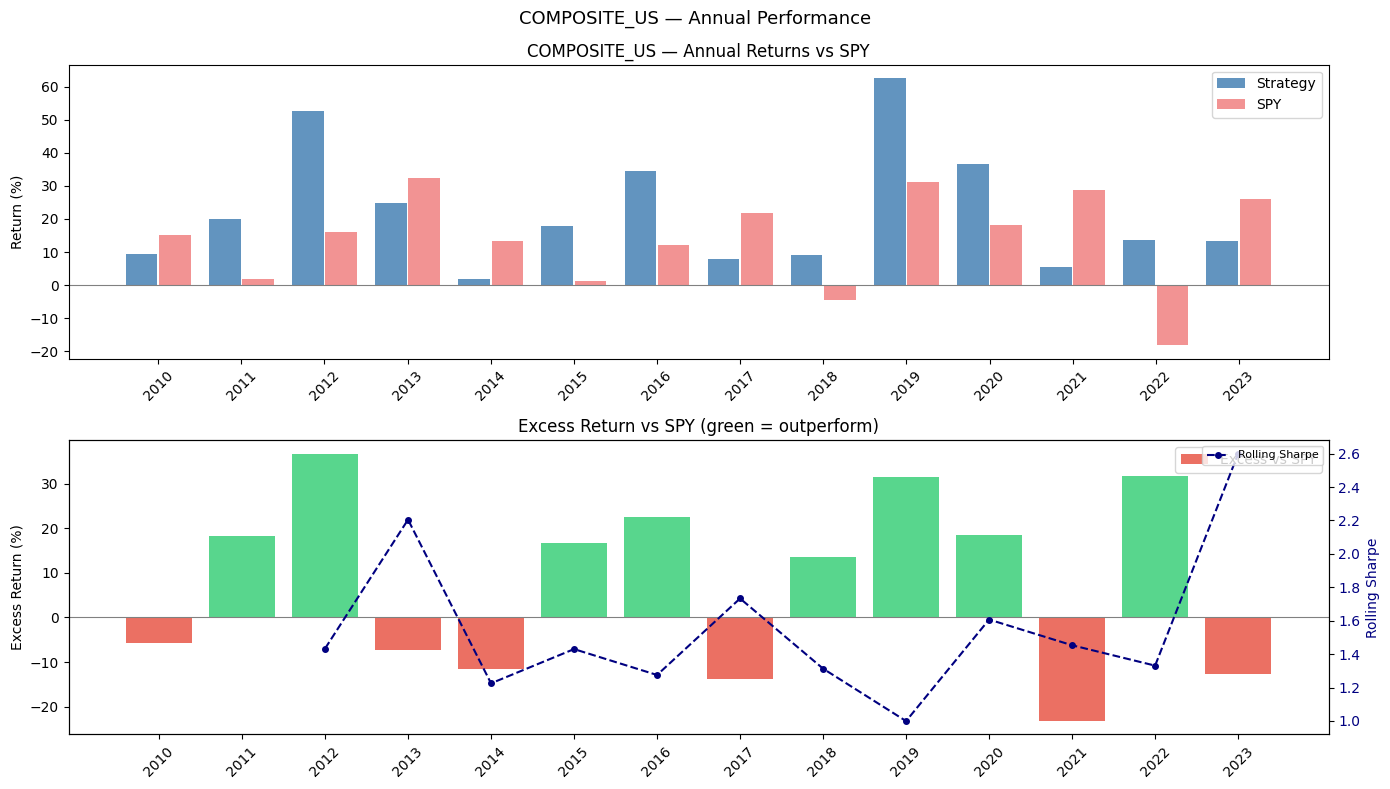

,port_pct,spy_pct,excess_vs_spy,n_picks,rolling_sharpe
year,,,,,
2010,9.3500,15.0600,-5.7100,20,NaN
2011,20.1400,1.9000,18.2400,20,NaN
2012,52.6600,15.9900,36.6700,20,1.4330
2013,24.9900,32.3100,-7.3100,20,2.2050
2014,1.7900,13.4600,-11.6700,20,1.2250
2015,17.8500,1.2300,16.6200,20,1.4300
2016,34.5700,12.0000,22.5700,20,1.2750
2017,7.8700,21.7100,-13.8400,20,1.7330
2018,9.0700,-4.5700,13.6400,20,1.3130


In [21]:
# ── 4a: Annual returns chart ──────────────────────────────────────────────────
if sreg_raw and SCREENER_REGISTRY_ID in sreg_raw.get('screeners', {}):
    s4a = sreg_raw['screeners'][SCREENER_REGISTRY_ID]
    ann_ret = s4a.get('annual_returns', [])
    if ann_ret:
        df_ann = pd.DataFrame(ann_ret)
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))
        ax = axes[0]
        years = df_ann['year']
        x = range(len(years))
        ax.bar([i - 0.2 for i in x], df_ann['port_pct'], width=0.38, label='Strategy',
               color='steelblue', alpha=0.85)
        ax.bar([i + 0.2 for i in x], df_ann['spy_pct'],  width=0.38, label='SPY',
               color='lightcoral', alpha=0.85)
        ax.axhline(0, color='gray', linewidth=0.8)
        ax.set_xticks(list(x))
        ax.set_xticklabels(years, rotation=45)
        ax.set_ylabel('Return (%)')
        ax.set_title(f'{SCREENER_REGISTRY_ID} — Annual Returns vs SPY')
        ax.legend()
        ax2 = axes[1]
        excess_vals = df_ann['excess_vs_spy'] if 'excess_vs_spy' in df_ann.columns else df_ann.get('excess_pct', [0]*len(x))
        ax2.bar(list(x), excess_vals,
                color=['#2ecc71' if v >= 0 else '#e74c3c' for v in excess_vals],
                alpha=0.8, label='Excess vs SPY')
        ax2.axhline(0, color='gray', linewidth=0.8)
        ax2.set_xticks(list(x))
        ax2.set_xticklabels(years, rotation=45)
        ax2.set_ylabel('Excess Return (%)')
        ax2.set_title('Excess Return vs SPY (green = outperform)')
        ax2.legend()
        if 'rolling_sharpe' in df_ann.columns and df_ann['rolling_sharpe'].notna().sum() > 2:
            ax3 = ax2.twinx()
            ax3.plot(list(x), df_ann['rolling_sharpe'], color='navy', linewidth=1.5,
                     linestyle='--', marker='o', markersize=4, label='Rolling Sharpe')
            ax3.set_ylabel('Rolling Sharpe', color='navy')
            ax3.tick_params(axis='y', labelcolor='navy')
            ax3.legend(loc='upper right', fontsize=8)
        plt.suptitle(f'{SCREENER_REGISTRY_ID} — Annual Performance', fontsize=13)
        plt.tight_layout()
        plt.show()
        table_cols = [c for c in ['year', 'port_pct', 'spy_pct', 'excess_vs_spy',
                                   'n_picks', 'rolling_sharpe'] if c in df_ann.columns]
        display(df_ann[table_cols].set_index('year'))
    else:
        print(f"No annual_returns data for {SCREENER_REGISTRY_ID}.")
else:
    print("screener_registry.json not loaded or SCREENER_REGISTRY_ID not found.")

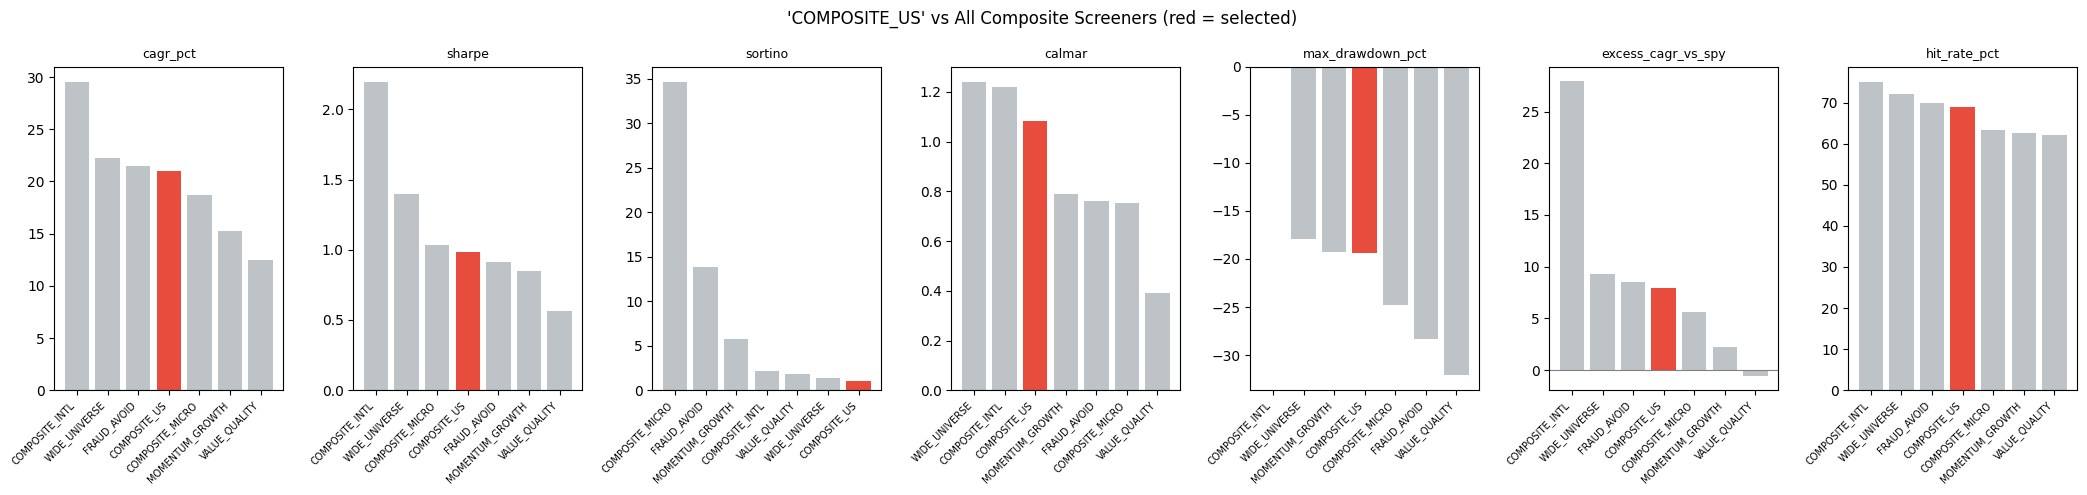

In [22]:
# ── 4a: Composite screener vs peers comparison ────────────────────────────────
if not screeners_df.empty and SCREENER_REGISTRY_ID in screeners_df['id'].values:
    metrics_4a = ['cagr_pct', 'sharpe', 'sortino', 'calmar', 'max_drawdown_pct',
                  'excess_cagr_vs_spy', 'hit_rate_pct']
    metrics_4a = [m for m in metrics_4a if m in screeners_df.columns]
    fig, axes = plt.subplots(1, len(metrics_4a), figsize=(3 * len(metrics_4a), 5))
    if len(metrics_4a) == 1:
        axes = [axes]
    for ax, metric in zip(axes, metrics_4a):
        sorted_s = screeners_df.sort_values(metric, ascending=False).reset_index(drop=True)
        colors_p = ['#e74c3c' if sid == SCREENER_REGISTRY_ID else '#bdc3c7'
                    for sid in sorted_s['id']]
        ax.bar(sorted_s['id'], sorted_s[metric], color=colors_p, edgecolor='none')
        ax.set_xticklabels(sorted_s['id'], rotation=45, ha='right', fontsize=7)
        ax.set_title(metric, fontsize=9)
        ax.axhline(0, color='gray', linewidth=0.8)
    plt.suptitle(f"'{SCREENER_REGISTRY_ID}' vs All Composite Screeners (red = selected)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    if screeners_df.empty:
        print("No screener registry data loaded. Run: python3 scripts/build_screener_registry.py")
    else:
        print(f"'{SCREENER_REGISTRY_ID}' not found. Available: {screeners_df['id'].tolist()}")

### 4b. Individual Alpha Signal Deep Dive — `SCREENER_ID`
> Full performance profile for the selected individual signal from `alpha_registry.json`.  
> **Change `SCREENER_ID` in Config** to switch signals. The cells below show detailed analysis for that signal.

In [23]:
# ── Load screener profile from registry ──────────────────────────────────────
screener_matches = signals[signals['signal_id'] == SCREENER_ID]

if screener_matches.empty:
    print(f"⚠ SCREENER_ID='{SCREENER_ID}' not found in alpha_registry.")
    print(f"Available: {signals['signal_id'].tolist()}")
else:
    scr = screener_matches.iloc[0]
    print(f"{'═'*55}")
    print(f"  SCREENER: {scr['signal_id']}")
    print(f"{'═'*55}")
    show_fields = [
        'category', 'horizon', 'market', 'selected',
        'ic_mean', 'icir',
        'cagr_pct', 'cagr_bootstrap_mean_pct', 'cagr_bootstrap_1sigma_pct',
        'sharpe', 'sharpe_bootstrap_mean', 'sharpe_bootstrap_1sigma',
        'sortino', 'calmar',
        'max_drawdown_pct', 'excess_cagr_vs_spy', 'beta_vs_spy',
        'hit_rate_pct', 'n_years', 'top_n', 'cost_bps',
    ]
    for f in show_fields:
        if f in scr and pd.notna(scr[f]):
            print(f"  {f:35} {scr[f]}")

    if 'features_used' in scr and isinstance(scr['features_used'], list):
        print(f"\n  Features used ({len(scr['features_used'])}):\n  {scr['features_used']}")

═══════════════════════════════════════════════════════
  SCREENER: ml_3y_oof
═══════════════════════════════════════════════════════
  category                            ml
  horizon                             3y
  market                              all
  selected                            True
  ic_mean                             0.3352
  icir                                5.2221
  cagr_pct                            32.15
  cagr_bootstrap_mean_pct             30.33
  cagr_bootstrap_1sigma_pct           5.79
  sharpe                              1.167
  sharpe_bootstrap_mean               1.509
  sharpe_bootstrap_1sigma             0.434
  sortino                             1.167
  calmar                              0.644
  max_drawdown_pct                    0.0
  excess_cagr_vs_spy                  20.23
  beta_vs_spy                         0.516
  hit_rate_pct                        77.0
  n_years                             10
  top_n                               20
  c

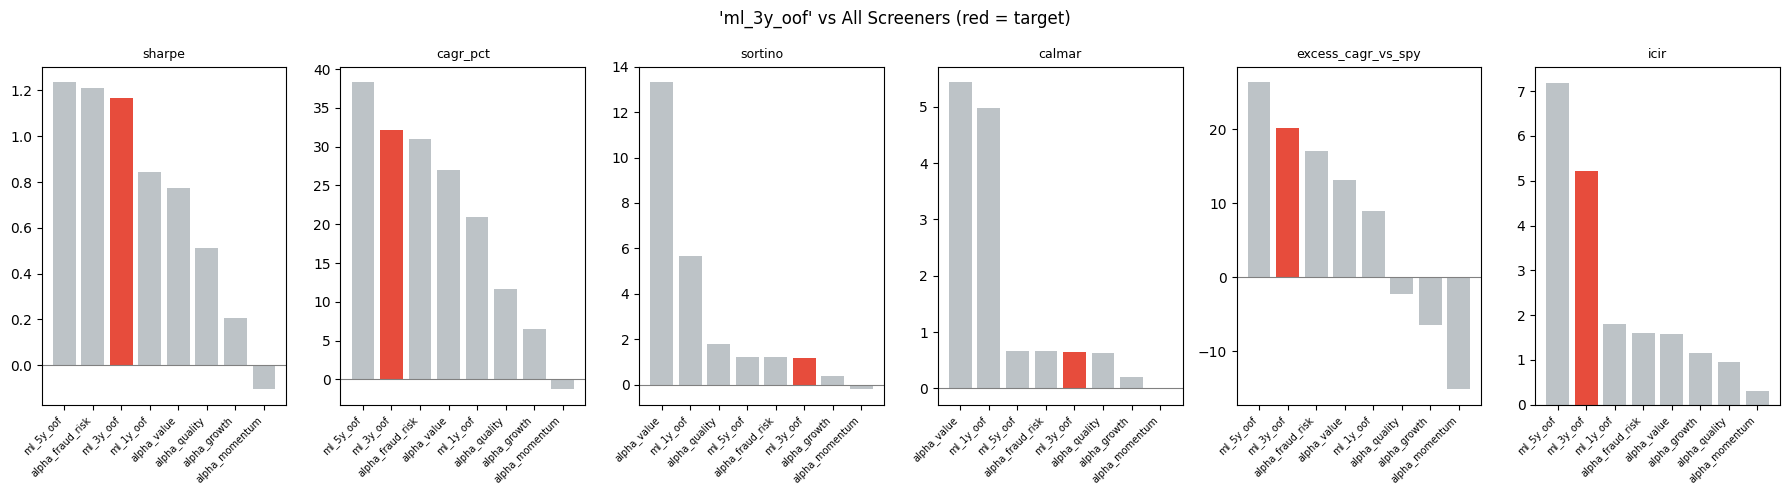

In [24]:
# ── Screener vs peers — ranked comparison chart ───────────────────────────────
if not screener_matches.empty:
    metrics = ['sharpe', 'cagr_pct', 'sortino', 'calmar', 'excess_cagr_vs_spy', 'icir']
    metrics_avail = [m for m in metrics if m in signals.columns]

    fig, axes = plt.subplots(1, len(metrics_avail), figsize=(3 * len(metrics_avail), 5))
    if len(metrics_avail) == 1:
        axes = [axes]

    for ax, metric in zip(axes, metrics_avail):
        sorted_signals = signals.sort_values(metric, ascending=False).reset_index(drop=True)
        target_rank = sorted_signals[sorted_signals['signal_id'] == SCREENER_ID].index
        colors = ['#e74c3c' if s == SCREENER_ID else '#bdc3c7' for s in sorted_signals['signal_id']]
        ax.bar(sorted_signals['signal_id'], sorted_signals[metric], color=colors, edgecolor='none')
        ax.set_xticklabels(sorted_signals['signal_id'], rotation=45, ha='right', fontsize=7)
        ax.set_title(metric, fontsize=9)
        ax.axhline(0, color='gray', linewidth=0.8)

    plt.suptitle(f"'{SCREENER_ID}' vs All Screeners (red = target)", fontsize=12)
    plt.tight_layout()
    plt.show()

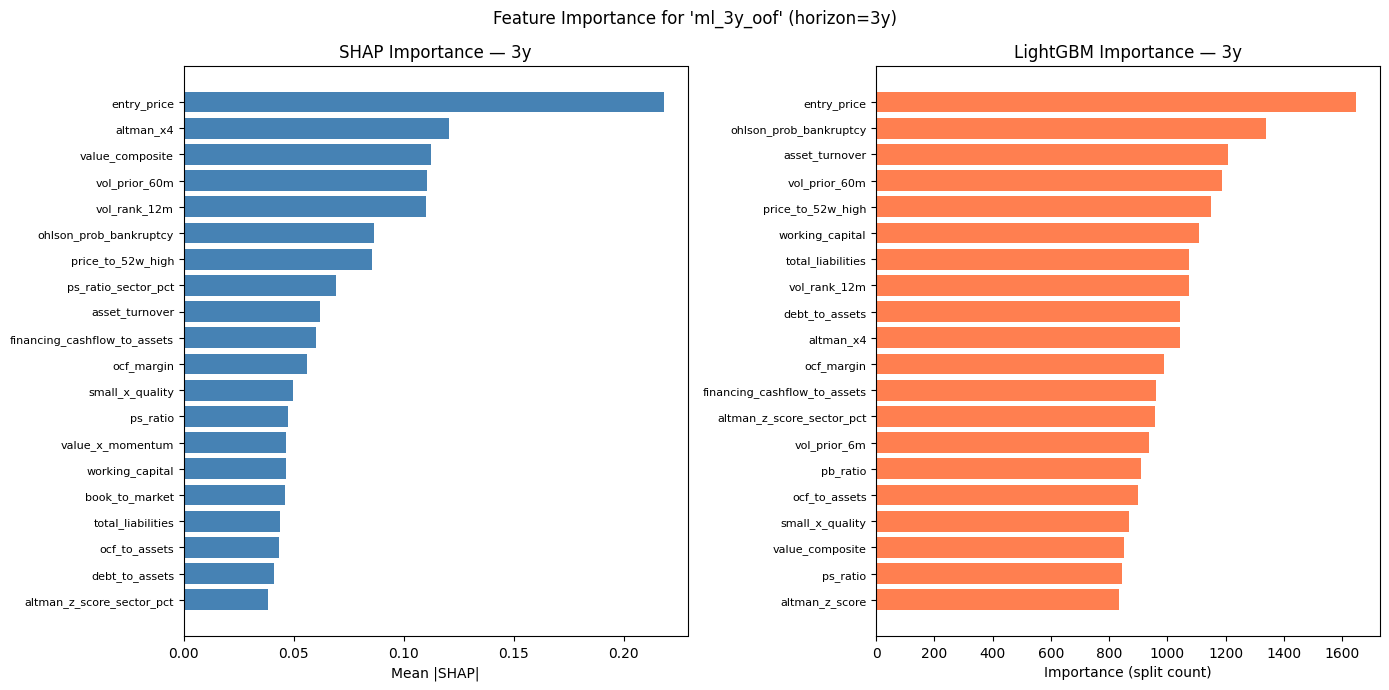

In [25]:
# ── SHAP importance for screener's horizon (if ML screener) ───────────────────
if not screener_matches.empty:
    # Determine horizon from screener id (ml_3y_oof -> 3y; alpha_value -> use LIVE_HORIZON)
    horizon_map = {'ml_6m_oof': '6m', 'ml_1y_oof': '1y', 'ml_2y_oof': '2y',
                   'ml_3y_oof': '3y', 'ml_5y_oof': '5y'}
    scr_horizon = horizon_map.get(SCREENER_ID, LIVE_HORIZON)

    shap_path = REPORTS / f'shap_importance_{scr_horizon}.csv'
    feat_path = REPORTS / f'feature_importance_{scr_horizon}.csv'

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    if shap_path.exists():
        df_shap = pd.read_csv(shap_path).head(TOP_FEATURES_N).sort_values('shap_mean_abs')
        axes[0].barh(df_shap['feature'], df_shap['shap_mean_abs'], color='steelblue')
        axes[0].set_title(f'SHAP Importance — {scr_horizon}')
        axes[0].set_xlabel('Mean |SHAP|')
        axes[0].tick_params(axis='y', labelsize=8)
    else:
        axes[0].text(0.5, 0.5, f'shap_importance_{scr_horizon}.csv not found',
                     ha='center', va='center', transform=axes[0].transAxes)

    if feat_path.exists():
        df_feat = pd.read_csv(feat_path).head(TOP_FEATURES_N).sort_values('importance')
        axes[1].barh(df_feat['feature'], df_feat['importance'], color='coral')
        axes[1].set_title(f'LightGBM Importance — {scr_horizon}')
        axes[1].set_xlabel('Importance (split count)')
        axes[1].tick_params(axis='y', labelsize=8)
    else:
        axes[1].text(0.5, 0.5, f'feature_importance_{scr_horizon}.csv not found',
                     ha='center', va='center', transform=axes[1].transAxes)

    plt.suptitle(f"Feature Importance for '{SCREENER_ID}' (horizon={scr_horizon})", fontsize=12)
    plt.tight_layout()
    plt.show()

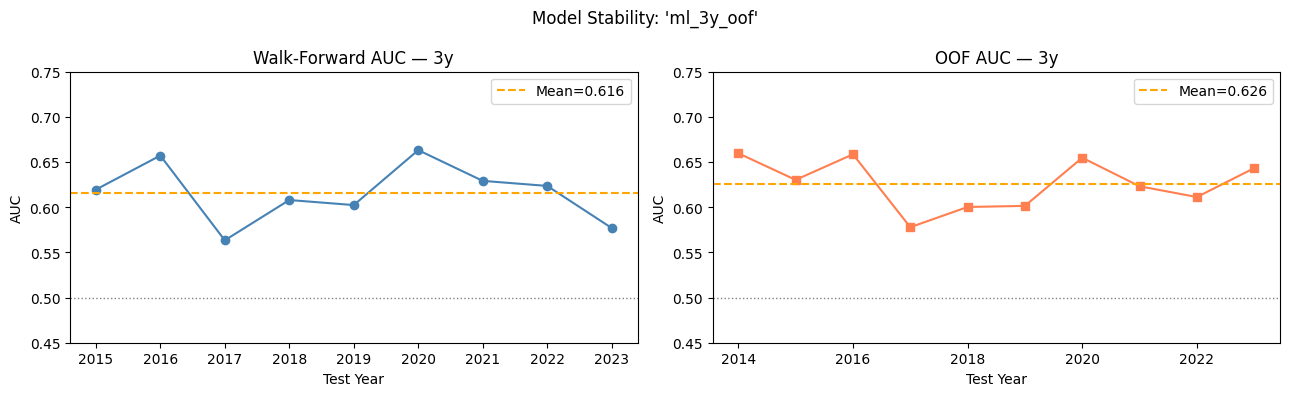

In [26]:
# ── Walk-forward AUC for this screener's horizon ─────────────────────────────
if not screener_matches.empty:
    wf_path = REPORTS / f'walk_forward_auc_{scr_horizon}.csv'
    oof_path = REPORTS / f'oof_auc_{scr_horizon}.csv'

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    if wf_path.exists():
        df_wf = pd.read_csv(wf_path).sort_values('test_year')
        axes[0].plot(df_wf['test_year'], df_wf['auc'], marker='o', color='steelblue')
        axes[0].axhline(0.50, color='gray', linestyle=':', linewidth=1)
        axes[0].axhline(df_wf['auc'].mean(), color='orange', linestyle='--',
                        label=f'Mean={df_wf["auc"].mean():.3f}')
        axes[0].set_xlabel('Test Year')
        axes[0].set_ylabel('AUC')
        axes[0].set_title(f'Walk-Forward AUC — {scr_horizon}')
        axes[0].legend()
        axes[0].set_ylim(0.45, 0.75)

    if oof_path.exists():
        df_oof = pd.read_csv(oof_path).sort_values('test_year')
        axes[1].plot(df_oof['test_year'], df_oof['auc'], marker='s', color='coral')
        axes[1].axhline(0.50, color='gray', linestyle=':', linewidth=1)
        axes[1].axhline(df_oof['auc'].mean(), color='orange', linestyle='--',
                        label=f'Mean={df_oof["auc"].mean():.3f}')
        axes[1].set_xlabel('Test Year')
        axes[1].set_ylabel('AUC')
        axes[1].set_title(f'OOF AUC — {scr_horizon}')
        axes[1].legend()
        axes[1].set_ylim(0.45, 0.75)

    plt.suptitle(f"Model Stability: '{SCREENER_ID}'", fontsize=12)
    plt.tight_layout()
    plt.show()

In [27]:
# ── Screener bootstrap confidence summary ────────────────────────────────────
if not screener_matches.empty:
    print(f"\n{'─'*50}")
    print(f"Bootstrap confidence for '{SCREENER_ID}'")
    print(f"{'─'*50}")

    bs_fields = [
        ('CAGR point estimate',     'cagr_pct',                   '%'),
        ('CAGR bootstrap mean',     'cagr_bootstrap_mean_pct',    '%'),
        ('CAGR ± 1σ',              'cagr_bootstrap_1sigma_pct',   '%'),
        ('Sharpe point estimate',   'sharpe',                     ''),
        ('Sharpe bootstrap mean',   'sharpe_bootstrap_mean',      ''),
        ('Sharpe ± 1σ',            'sharpe_bootstrap_1sigma',     ''),
        ('Max drawdown',           'max_drawdown_pct',             '%'),
        ('Excess CAGR vs SPY',     'excess_cagr_vs_spy',          '%'),
        ('Hit rate',               'hit_rate_pct',                 '%'),
        ('Beta vs SPY',            'beta_vs_spy',                  ''),
    ]
    for label, field, unit in bs_fields:
        val = scr.get(field, None)
        if val is not None and pd.notna(val):
            print(f"  {label:35} {val:>8.3f}{unit}")


──────────────────────────────────────────────────
Bootstrap confidence for 'ml_3y_oof'
──────────────────────────────────────────────────
  CAGR point estimate                   32.150%
  CAGR bootstrap mean                   30.330%
  CAGR ± 1σ                              5.790%
  Sharpe point estimate                  1.167
  Sharpe bootstrap mean                  1.509
  Sharpe ± 1σ                            0.434
  Max drawdown                           0.000%
  Excess CAGR vs SPY                    20.230%
  Hit rate                              77.000%
  Beta vs SPY                            0.516


---
## 5. Live Picks — Today's Candidates
> **Run after the weekly data refresh.** Uses quality gates + composite alpha score.

In [28]:
# ── Load dataset ─────────────────────────────────────────────────────────────
if USE_HF:
    from huggingface_hub import hf_hub_download
    local_path = hf_hub_download(repo_id=HF_REPO, filename='historical_dataset_clean.parquet',
                                 repo_type='dataset')
    df_full = pd.read_parquet(local_path)
else:
    df_full = pd.read_parquet(DATA / 'historical_dataset_clean.parquet')

print(f'Dataset loaded: {df_full.shape}')
print(f'Markets: {df_full["market"].value_counts().to_dict()}')

Dataset loaded: (58190, 367)
Markets: {'US': 44059, 'CA': 8955, 'KR': 2538, 'BR': 688, 'JP': 517, 'DE': 356, 'FR': 193, 'IT': 192, 'ES': 169, 'SE': 139, 'FI': 116, 'NL': 115, 'PT': 82, 'DK': 71}


In [29]:
# ── Get latest annual row per ticker ─────────────────────────────────────────
df = df_full[df_full['period_type'] == 'annual'].copy()
df = (
    df.sort_values('fiscal_year', ascending=False)
      .groupby(['ticker', 'market'], sort=False)
      .first()
      .reset_index()
)
if MARKETS:
    df = df[df['market'].isin(MARKETS)]
print(f'Latest annual rows: {len(df):,}')

# ── Size filter ───────────────────────────────────────────────────────────────
n0 = len(df)
if 'market_cap_at_filing' in df.columns:
    df = df[df['market_cap_at_filing'].notna() & (df['market_cap_at_filing'] >= MIN_MARKET_CAP)]
    if MAX_MARKET_CAP:
        df = df[df['market_cap_at_filing'] <= MAX_MARKET_CAP]
print(f'After size filter: {len(df):,} / {n0:,}')

# ── Quality gates ─────────────────────────────────────────────────────────────
n1 = len(df)
if 'piotroski_f_score' in df.columns: df = df[df['piotroski_f_score'] >= PIOTROSKI_MIN]
if 'beneish_m_score'   in df.columns: df = df[df['beneish_m_score']   <  BENEISH_MAX]
if 'altman_z_score'    in df.columns: df = df[df['altman_z_score']    >  ALTMAN_MIN]
print(f'After quality gates: {len(df):,} / {n1:,}')

# ── Margin of safety ─────────────────────────────────────────────────────────
n2 = len(df)
if APPLY_MOS:
    mos = pd.Series(True, index=df.index)
    if 'price_to_book' in df.columns: mos &= df['price_to_book'].isna() | (df['price_to_book'] <= PB_MAX)
    if 'fcf_yield'     in df.columns: mos &= df['fcf_yield'].isna()      | (df['fcf_yield']     >= FCF_YIELD_MIN)
    df = df[mos]
    print(f'After MoS gates: {len(df):,} / {n2:,}')

print(f'\nScreened universe: {len(df):,} stocks')

Latest annual rows: 7,625
After size filter: 1,986 / 7,625
After quality gates: 146 / 1,986
After MoS gates: 81 / 146

Screened universe: 81 stocks


In [30]:
# ── IC-weighted composite alpha ───────────────────────────────────────────────
# Pull IC weights from registry for selected signals
ic_weights = {
    row['signal_id']: row['ic_mean']
    for _, row in signals[signals['selected']].iterrows()
    if pd.notna(row.get('ic_mean'))
}
print(f'IC weights used: {ic_weights}')

def compute_composite(df, weights):
    composite = pd.Series(0.0, index=df.index)
    weight_sum = pd.Series(0.0, index=df.index)
    for col, w in weights.items():
        if col in df.columns:
            ranks = df[col].rank(pct=True)
            valid = ranks.notna()
            composite[valid] += ranks[valid] * w
            weight_sum[valid] += w
    return composite / weight_sum.clip(lower=1e-9)

df['composite_score'] = compute_composite(df, ic_weights)
df['label'] = df['ticker'] + ' (' + df['market'] + ')'
df['leverage_candidate'] = (
    df['beta_12m'].notna() & (df['beta_12m'] < BETA_MAX)
) if 'beta_12m' in df.columns else False

# Kelly sizing
f_full = (2.0 * df['composite_score'] - 1.0).clip(lower=0.0)
f_kelly = (f_full * HALF_KELLY).clip(upper=POSITION_CAP)
total = f_kelly.sum()
df['kelly_pct'] = ((f_kelly / total * 100) if total > 0 else f_kelly).round(2)

print(f'\nComposite score: mean={df["composite_score"].mean():.3f}  p90={df["composite_score"].quantile(0.9):.3f}')

IC weights used: {'alpha_value': 0.1521, 'alpha_quality': 0.0944, 'alpha_fraud_risk': 0.1989, 'ml_1y_oof': 0.1534, 'ml_3y_oof': 0.3352, 'ml_5y_oof': 0.3901}

Composite score: mean=0.506  p90=0.764


In [31]:
# ── Top LONG picks ────────────────────────────────────────────────────────────
display_cols = [
    'label', 'fiscal_year', 'market', 'composite_score',
    'alpha_value', 'alpha_quality', 'alpha_fraud_risk', 'ml_3y_oof',
    'piotroski_f_score', 'beneish_m_score', 'altman_z_score',
    'price_to_book', 'fcf_yield', 'market_cap_at_filing',
    'beta_12m', 'leverage_candidate', 'kelly_pct',
]
present_dc = [c for c in display_cols if c in df.columns]

longs = df.nlargest(TOP_N_LONG, 'composite_score')[present_dc].reset_index(drop=True)
if 'market_cap_at_filing' in longs.columns:
    longs['mktcap_$M'] = (longs['market_cap_at_filing'] / 1e6).round(1)
    longs = longs.drop(columns=['market_cap_at_filing'])
longs.index = range(1, len(longs) + 1)

print(f'Top {TOP_N_LONG} LONG candidates:')
longs

Top 25 LONG candidates:


,label,fiscal_year,market,composite_score,alpha_value,alpha_quality,alpha_fraud_risk,ml_3y_oof,piotroski_f_score,beneish_m_score,altman_z_score,price_to_book,fcf_yield,leverage_candidate,kelly_pct,mktcap_$M
1,JELD (US),2025,US,0.9604,0.8202,0.6541,0.9112,0.8682,6.0000,-2.7579,2.1424,0.2010,1.4436,False,2.9100,171.0000
2,VRA (US),2026,US,0.8705,0.7732,0.6992,0.7749,0.8180,6.0000,-2.7598,2.2120,0.4969,0.4973,False,2.9100,88.9000
3,FLNT.TO (CA),2025,CA,0.8489,0.7753,0.7000,0.9224,0.6150,6.0000,-3.0709,3.2752,0.3943,1.7828,False,2.9100,43.7000
4,VLGEA (US),2025,US,0.8413,0.7928,0.6259,0.7614,0.7675,8.0000,-2.3524,2.6538,0.3151,0.1372,False,2.9100,129.2000
5,CVGI (US),2025,US,0.8321,0.7964,0.4691,0.7266,0.8185,7.0000,-2.3027,2.8869,0.4547,0.3404,False,2.9100,54.6000
6,TTEC (US),2025,US,0.8172,0.7907,0.6475,0.8551,0.6832,5.0000,-2.5843,1.8309,NaN,0.7290,False,2.9100,105.5000
7,RGP (US),2025,US,0.7809,0.7971,0.6810,0.8025,0.6638,6.0000,-2.4978,3.1034,0.4460,0.4793,False,2.9100,166.1000
8,CRNT (US),2025,US,0.7754,0.6142,0.6747,0.8030,0.7083,7.0000,-2.4970,2.3414,1.3446,0.0936,False,2.9100,223.6000
9,DCM.TO (CA),2025,CA,0.7644,0.7252,0.6183,0.7999,0.6474,6.0000,-2.5469,1.8887,2.4517,0.2256,False,2.9100,91.7000
10,OSUR (US),2025,US,0.7582,0.7963,0.7721,0.9247,0.5998,7.0000,-3.0534,3.0630,0.6550,0.5688,False,2.9100,238.7000


In [32]:
# ── Top SHORT picks ───────────────────────────────────────────────────────────
short_cols = [
    'label', 'fiscal_year', 'market', 'composite_score',
    'alpha_fraud_risk', 'ml_3y_oof',
    'piotroski_f_score', 'beneish_m_score', 'altman_z_score',
    'fraud_suspect', 'montier_c_score', 'price_to_book', 'market_cap_at_filing',
]
short_present = [c for c in short_cols if c in df.columns]
shorts = df.nsmallest(TOP_N_SHORT, 'composite_score')[short_present].reset_index(drop=True)
if 'market_cap_at_filing' in shorts.columns:
    shorts['mktcap_$M'] = (shorts['market_cap_at_filing'] / 1e6).round(1)
    shorts = shorts.drop(columns=['market_cap_at_filing'])
shorts.index = range(1, len(shorts) + 1)

print(f'Top {TOP_N_SHORT} SHORT candidates:')
shorts

Top 15 SHORT candidates:


,label,fiscal_year,market,composite_score,alpha_fraud_risk,ml_3y_oof,piotroski_f_score,beneish_m_score,altman_z_score,fraud_suspect,montier_c_score,price_to_book,mktcap_$M
1,GH.TO (CA),2025,CA,0.1428,0.6503,0.4163,6.0000,-2.3356,2.3469,0,0.2000,1.7579,200.9000
2,GENI (US),2025,US,0.1633,0.5212,0.4714,5.0000,-2.8702,1.9505,0,0.6667,-24.2809,39.5000
3,PED (US),2025,US,0.1808,0.4715,0.3692,7.0000,-1.9827,2.0855,0,0.0000,0.7057,71.6000
4,FLXS (US),2025,US,0.1843,0.5500,0.4844,5.0000,-2.2362,2.9236,0,0.6667,1.7148,225.6000
5,UG (US),2025,US,0.2072,0.6505,0.3519,6.0000,-2.4717,10.1975,0,0.3333,2.6464,30.1000
6,NCSM (US),2025,US,0.2100,0.6805,0.4714,6.0000,-2.4073,3.0253,0,0.4000,1.1274,111.4000
7,RSRV (US),2025,US,0.2115,0.6107,0.4253,6.0000,-3.0293,4.4435,0,0.1667,1.1510,35.0000
8,BNSOF (US),2022,US,0.2191,0.5992,0.3914,7.0000,-2.1306,2.0412,0,0.4000,1.4108,21.4000
9,UTMD (US),2025,US,0.2365,0.6583,0.5246,5.0000,-2.1739,13.4605,0,0.4000,1.7478,205.2000
10,ELTK (US),2025,US,0.2706,0.6902,0.4925,6.0000,-2.5614,3.4413,0,0.5000,1.3431,55.3000


══════════════════════════════════════════════════
PORTFOLIO SUMMARY
══════════════════════════════════════════════════
  Universe (screened) : 81 stocks
  Long picks          : 25
  Short picks         : 15
  Horizon             : 3y

Market breakdown (longs):
market
US    16
CA     9

Leverage-eligible: 0 / 25


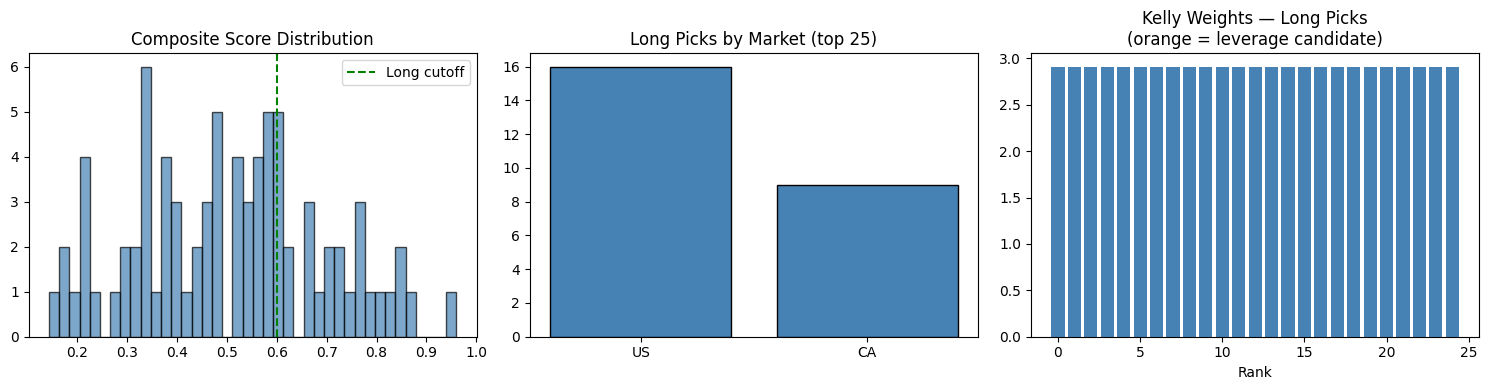

In [33]:
# ── Portfolio summary + charts ────────────────────────────────────────────────
top_longs_df = df.nlargest(TOP_N_LONG, 'composite_score')

print(f"{'═'*50}")
print('PORTFOLIO SUMMARY')
print(f"{'═'*50}")
print(f'  Universe (screened) : {len(df):,} stocks')
print(f'  Long picks          : {TOP_N_LONG}')
print(f'  Short picks         : {TOP_N_SHORT}')
print(f'  Horizon             : {LIVE_HORIZON}')
print()
print('Market breakdown (longs):')
print(top_longs_df['market'].value_counts().to_string())

if 'leverage_candidate' in top_longs_df.columns:
    print(f"\nLeverage-eligible: {top_longs_df['leverage_candidate'].sum()} / {TOP_N_LONG}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['composite_score'], bins=40, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(top_longs_df['composite_score'].min(), color='green', linestyle='--', label='Long cutoff')
axes[0].set_title('Composite Score Distribution')
axes[0].legend()

mc = top_longs_df['market'].value_counts()
axes[1].bar(mc.index, mc.values, color='steelblue', edgecolor='black')
axes[1].set_title(f'Long Picks by Market (top {TOP_N_LONG})')

kw = top_longs_df.nlargest(TOP_N_LONG, 'composite_score')['kelly_pct'].values
lev_flags = top_longs_df.nlargest(TOP_N_LONG, 'composite_score')['leverage_candidate'].values \
    if 'leverage_candidate' in top_longs_df.columns else [False] * TOP_N_LONG
bar_colors = ['orange' if lc else 'steelblue' for lc in lev_flags]
axes[2].bar(range(len(kw)), kw, color=bar_colors)
axes[2].set_title('Kelly Weights — Long Picks\n(orange = leverage candidate)')
axes[2].set_xlabel('Rank')

plt.tight_layout()
plt.show()

In [34]:
# ── Export picks ──────────────────────────────────────────────────────────────
from datetime import date
today = date.today().isoformat()

longs.to_csv(ROOT / 'reports' / f'screener_longs_{today}.csv', index=False)
shorts.to_csv(ROOT / 'reports' / f'screener_shorts_{today}.csv', index=False)
print(f'Exported to reports/screener_longs_{today}.csv and screener_shorts_{today}.csv')

Exported to reports/screener_longs_2026-05-15.csv and screener_shorts_2026-05-15.csv


---
## 6. Decision Tree Screener — Rule-Based Top 100
> **Interpretable rule-based screener.** Trains a shallow decision tree on the same features as LightGBM, extracts key branching rules, then scores the full current universe and ranks the top 100 companies by DT probability.
>
> Configure `DT_HORIZON` and `DT_MAX_DEPTH` in the next cell.

In [35]:
# ── Config ───────────────────────────────────────────────────────────────────
DT_HORIZONS  = ['6m', '1y', '2y', '3y', '5y']
DT_MAX_DEPTH = 5
TOP_N_DT     = 100

# ── Filters (set to None to disable) ─────────────────────────────────────────
DT_MARKETS        = None      # e.g. ['US', 'CA'] or None for all markets
DT_MIN_SCORE      = 0.0       # min dt_score threshold (0.0 = no filter)
DT_MIN_MARKET_CAP = None      # e.g. 10_000_000 or None
DT_PIOTROSKI_MIN  = None      # e.g. 5 or None
DT_BENEISH_MAX    = None      # e.g. -1.78 or None (lower = less manipulation risk)
DT_ALTMAN_MIN     = None      # e.g. 1.81 or None (higher = less distress risk)

from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import roc_auc_score

df_dt = pd.read_parquet(DATA / 'historical_dataset_clean.parquet')

dt_models     = {}
dt_feats_by_h = {}
X_train_by_h  = {}
y_train_by_h  = {}

print(f"{'Horizon':<8} {'Depth':<6} {'Features':<10} {'Train AUC':<12} {'Train Rows'}")
print('─' * 50)

for h in DT_HORIZONS:
    with open(MODELS / f'feature_sets_{h}.json') as f:
        dt_feats_all_h = json.load(f)['features']

    target_col_h = f'beat_local_market_{h}'
    dt_feats_h   = [c for c in dt_feats_all_h if c in df_dt.columns]

    train_mask_h = df_dt[target_col_h].notna()
    X_tr = df_dt.loc[train_mask_h, dt_feats_h].fillna(
               df_dt.loc[train_mask_h, dt_feats_h].median())
    y_tr = df_dt.loc[train_mask_h, target_col_h]

    model_h = DecisionTreeClassifier(max_depth=DT_MAX_DEPTH, min_samples_leaf=30, random_state=42)
    model_h.fit(X_tr, y_tr)
    auc_h = roc_auc_score(y_tr, model_h.predict_proba(X_tr)[:, 1])

    dt_models[h]     = model_h
    dt_feats_by_h[h] = dt_feats_h
    X_train_by_h[h]  = X_tr
    y_train_by_h[h]  = y_tr

    print(f"{h:<8} {DT_MAX_DEPTH:<6} {len(dt_feats_h):<10} {auc_h:<12.4f} {len(X_tr):,}")

print()
for h in DT_HORIZONS:
    print(f"\n── Decision Rules  horizon={h}  (depth ≤ 3) {'─'*30}")
    print(export_text(dt_models[h], feature_names=dt_feats_by_h[h], max_depth=3, show_weights=True)[:2000])


Horizon  Depth  Features   Train AUC    Train Rows
──────────────────────────────────────────────────


6m       5      36         0.5937       50,358


1y       5      37         0.5987       49,172


2y       5      36         0.6286       42,552


3y       5      38         0.6506       36,222


5y       5      35         0.6539       24,591


── Decision Rules  horizon=6m  (depth ≤ 3) ──────────────────────────────
|--- vol_prior_60m <= 0.69
|   |--- value_x_momentum <= 0.31
|   |   |--- ev_revenue <= 83.13
|   |   |   |--- vol_prior_60m <= 0.46
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- vol_prior_60m >  0.46
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- ev_revenue >  83.13
|   |   |   |--- ocf_margin <= -51.49
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- ocf_margin >  -51.49
|   |   |   |   |--- truncated branch of depth 2
|   |--- value_x_momentum >  0.31
|   |   |--- altman_x4 <= 0.10
|   |   |   |--- ps_ratio_sector_pct <= 0.52
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- ps_ratio_sector_pct >  0.52
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- altman_x4 >  0.10
|   |   |   |--- altman_x5 <= 0.05
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- altman_x5 >  0.

In [36]:
# ── Score full universe per horizon and display top-100 ───────────────────────
from datetime import date as _date
_today = _date.today().isoformat()

latest_dt_base = (
    df_dt[df_dt['period_type'] == 'annual']
    .sort_values('fiscal_year', ascending=False)
    .groupby(['ticker', 'market'], sort=False)
    .first()
    .reset_index()
)
n0 = len(latest_dt_base)
print(f'Base universe: {n0:,} stocks\n')

dt_top_by_h = {}

for h in DT_HORIZONS:
    dt_feats_h = dt_feats_by_h[h]
    X_tr       = X_train_by_h[h]
    model_h    = dt_models[h]

    latest_dt = latest_dt_base.copy()
    X_score_h = latest_dt[dt_feats_h].fillna(X_tr.median())
    latest_dt['dt_score'] = model_h.predict_proba(X_score_h)[:, 1]

    # ── Apply filters ─────────────────────────────────────────────────────────
    if DT_MARKETS:
        latest_dt = latest_dt[latest_dt['market'].isin(DT_MARKETS)]
    if DT_MIN_MARKET_CAP and 'market_cap_at_filing' in latest_dt.columns:
        latest_dt = latest_dt[latest_dt['market_cap_at_filing'].notna() &
                              (latest_dt['market_cap_at_filing'] >= DT_MIN_MARKET_CAP)]
    if DT_PIOTROSKI_MIN is not None and 'piotroski_f_score' in latest_dt.columns:
        latest_dt = latest_dt[latest_dt['piotroski_f_score'] >= DT_PIOTROSKI_MIN]
    if DT_BENEISH_MAX is not None and 'beneish_m_score' in latest_dt.columns:
        latest_dt = latest_dt[latest_dt['beneish_m_score'] < DT_BENEISH_MAX]
    if DT_ALTMAN_MIN is not None and 'altman_z_score' in latest_dt.columns:
        latest_dt = latest_dt[latest_dt['altman_z_score'] > DT_ALTMAN_MIN]
    if DT_MIN_SCORE > 0:
        latest_dt = latest_dt[latest_dt['dt_score'] >= DT_MIN_SCORE]

    name_col = 'name' if 'name' in latest_dt.columns else None
    display_cols_h = ['ticker'] + ([name_col] if name_col else []) + ['fiscal_year', 'market', 'dt_score']
    for c in ['alpha_value', 'alpha_quality', 'alpha_momentum', 'alpha_growth',
              'alpha_fraud_risk', 'ml_1y_oof', 'ml_3y_oof']:
        if c in latest_dt.columns:
            display_cols_h.append(c)

    top_dt_h = (
        latest_dt.nlargest(TOP_N_DT, 'dt_score')[display_cols_h]
        .reset_index(drop=True)
    )
    top_dt_h.index += 1
    top_dt_h['dt_score'] = top_dt_h['dt_score'].round(4)
    dt_top_by_h[h] = top_dt_h

    print(f"{'='*60}")
    print(f"TOP {TOP_N_DT} — Decision Tree Screener  (horizon: {h})")
    print(f"After filters: {len(latest_dt):,} / {n0:,}")
    print(f"{'='*60}")

    fmt_h = {'dt_score': '{:.4f}'}
    for c in ['alpha_value', 'alpha_quality', 'alpha_momentum', 'alpha_growth',
              'alpha_fraud_risk', 'ml_1y_oof', 'ml_3y_oof']:
        if c in top_dt_h.columns:
            fmt_h[c] = '{:.4f}'

    display(
        top_dt_h.style
                .background_gradient(subset=['dt_score'], cmap='Greens')
                .format(fmt_h)
                .set_caption(f'DT Screener — {h} horizon, depth {DT_MAX_DEPTH}')
    )

    print(f'Market distribution ({h}):')
    print(top_dt_h['market'].value_counts().to_string())

    out_path = ROOT / 'reports' / f'dt_screener_top100_{h}_{_today}.csv'
    top_dt_h.to_csv(out_path, index=True)
    print(f'Exported → {out_path.name}\n')


Base universe: 7,625 stocks

TOP 100 — Decision Tree Screener  (horizon: 6m)
After filters: 7,625 / 7,625


,ticker,name,fiscal_year,market,dt_score,alpha_value,alpha_quality,alpha_momentum,alpha_growth,alpha_fraud_risk,ml_1y_oof,ml_3y_oof
1,CGO.TO,Cogeco Inc.,2025,CA,0.8244,0.6920,0.7667,0.3844,0.4173,0.7729,0.6333,0.7190
2,CBK.DE,Commerzbank AG,2025,DE,0.8244,0.6167,0.0385,0.8542,0.6731,0.1043,0.4897,0.5316
3,JXN,Jackson Financial Inc.,2025,US,0.8244,0.6538,0.5595,0.8144,0.1826,0.6641,0.7443,0.5662
4,FFIC,FLUSHING FINANCIAL CORP,2025,US,0.8244,0.3979,0.4370,0.6762,0.4543,0.4011,0.5502,0.4648
5,LB.TO,Laurentian Bank of Canada,2025,CA,0.8244,0.5867,0.5823,0.5994,0.7875,0.5413,0.7725,0.6630
6,BNP.PA,BNP Paribas,2025,FR,0.8244,0.8545,0.4075,0.6167,0.7734,0.5306,0.9087,0.7682
7,HFBL,"Home Federal Bancorp, Inc. of Louisiana",2025,US,0.8244,0.4316,0.2934,0.5788,0.2231,0.3933,0.6195,0.5578
8,BMPS.MI,Banca Monte dei Paschi di Siena,2025,IT,0.8244,0.7946,0.1783,0.5299,0.7791,0.4815,0.8890,0.7995
9,GLE.PA,Société Générale,2025,FR,0.8244,0.6424,0.0800,0.9417,0.5844,0.4583,0.9089,0.8970
10,DBK.DE,Deutsche Bank AG,2025,DE,0.8244,0.6893,0.5087,0.8542,0.9334,0.6222,0.8206,0.6936


Market distribution (6m):
market
US    50
CA    16
JP     7
NL     5
DE     4
IT     4
ES     4
FR     3
SE     3
DK     2
PT     1
FI     1
Exported → dt_screener_top100_6m_2026-05-15.csv



TOP 100 — Decision Tree Screener  (horizon: 1y)
After filters: 7,625 / 7,625


,ticker,name,fiscal_year,market,dt_score,alpha_value,alpha_quality,alpha_momentum,alpha_growth,alpha_fraud_risk,ml_1y_oof,ml_3y_oof
1,8601.T,Daiwa Securities Group Inc,2026,JP,0.9750,0.5973,0.5250,0.5000,0.6667,0.5778,0.9155,0.9174
2,CBK.DE,Commerzbank AG,2025,DE,0.9750,0.6167,0.0385,0.8542,0.6731,0.1043,0.4897,0.5316
3,GLE.PA,Société Générale,2025,FR,0.9750,0.6424,0.0800,0.9417,0.5844,0.4583,0.9089,0.8970
4,MSN,EMERSON RADIO CORP,2025,US,0.9750,0.5967,0.2574,0.4331,0.6214,0.4737,0.5552,0.6377
5,7182.T,Japan Post Bank Co,2025,JP,0.9750,0.6829,0.4139,0.5055,0.5820,0.6318,0.9152,0.8841
6,EHSI,Elite Health Systems Inc.,2022,US,0.9750,0.6047,0.4752,0.1874,0.0944,0.6408,0.6600,0.5424
7,TE,T1 Energy Inc.,2025,US,0.6452,0.2827,0.1760,0.9432,nan,0.3315,0.5065,0.5581
8,BBIO,"BridgeBio Pharma, Inc.",2025,US,0.6452,0.3163,0.0686,0.8509,0.1669,0.1792,0.4705,0.2364
9,TSHA,"Taysha Gene Therapies, Inc.",2025,US,0.6452,0.3918,0.3012,0.6986,0.5501,0.3888,0.4913,0.5867
10,NN,NEXTNAV INC.,2025,US,0.6452,0.4395,0.4057,0.5598,0.5224,0.4151,0.2437,0.1332


...

Market distribution (2y):
market
CA    52
US    41
JP     3
FR     2
DE     1
NL     1
Exported → dt_screener_top100_2y_2026-05-15.csv

TOP 100 — Decision Tree Screener  (horizon: 3y)
After filters: 7,625 / 7,625


,ticker,name,fiscal_year,market,dt_score,alpha_value,alpha_quality,alpha_momentum,alpha_growth,alpha_fraud_risk,ml_1y_oof,ml_3y_oof
1,RUS.TO,Russel Metals Inc.,2025,CA,0.6910,0.6500,0.5580,0.4245,0.4882,0.7650,0.5385,0.6734
2,RTX,RTX Corp,2025,US,0.6910,0.9615,0.5760,0.8139,0.3877,0.4537,0.5128,0.3595
3,CFW.TO,Calfrac Well Services Ltd.,2025,CA,0.6910,0.7111,0.6485,0.2935,0.7160,0.9126,0.5411,0.6929
4,PD.TO,Precision Drilling Corporation,2025,CA,0.6910,0.5458,0.7687,0.6602,0.2646,0.6951,0.5471,0.6206
5,PK,Park Hotels & Resorts Inc.,2025,US,0.6910,0.5620,0.6667,0.5251,0.5258,0.6677,0.5766,0.6957
6,G.MI,Generali,2025,IT,0.6910,0.7461,0.4561,0.5470,0.7177,0.5470,0.7544,0.7474
7,RSI.TO,Rogers Sugar Inc.,2025,CA,0.6910,0.6286,0.5850,0.5897,0.5921,0.8132,0.6012,0.6664
8,ANG-PD,American National Group Inc.,2025,US,0.6910,0.8682,0.5224,0.4675,0.7033,0.4804,0.6461,0.4444
9,PFGC,Performance Food Group Co,2025,US,0.6910,0.5676,0.5789,0.7679,0.8385,0.7736,0.6434,0.6715
10,FTT.TO,Finning International Inc.,2025,CA,0.6910,0.6402,0.5619,0.7323,0.4721,0.6999,0.5429,0.5332


Market distribution (3y):
market
US    58
CA    30
JP     4
IT     3
FR     3
NL     1
ES     1
Exported → dt_screener_top100_3y_2026-05-15.csv

TOP 100 — Decision Tree Screener  (horizon: 5y)
After filters: 7,625 / 7,625


,ticker,name,fiscal_year,market,dt_score,alpha_value,alpha_quality,alpha_momentum,alpha_growth,alpha_fraud_risk,ml_1y_oof,ml_3y_oof
1,SPGI.TO,S&P Global CDR (CAD Hedged),2025,CA,0.8857,0.7095,0.6764,nan,0.5349,0.6575,0.5924,0.6108
2,VRA,"Vera Bradley, Inc.",2026,US,0.7129,0.7732,0.6992,0.7968,0.4477,0.7749,0.6382,0.8180
3,BGS,"B&G Foods, Inc.",2026,US,0.7129,0.6141,0.3146,0.7283,0.2314,0.6594,0.6195,0.6730
4,CHPT,"ChargePoint Holdings, Inc.",2026,US,0.7129,0.5556,0.2894,0.1503,0.2770,0.5263,0.3565,0.3210
5,IRIX,IRIDEX CORP,2026,US,0.7129,0.5397,0.3651,0.8021,0.3265,0.4561,0.6537,0.7628
6,RET.V,Reitmans (Canada) Limited,2026,CA,0.7129,0.7870,0.4549,0.6222,0.1429,0.7053,0.5075,0.8511
7,FORR,"FORRESTER RESEARCH, INC.",2025,US,0.7129,0.6576,0.5853,0.2035,0.2093,0.6965,0.6003,0.6607
8,FOSL,"Fossil Group, Inc.",2025,US,0.7129,0.6703,0.5174,0.8643,0.2576,0.6139,0.4598,0.6827
9,CEIN,"CAMBER ENERGY, INC.",2025,US,0.7129,0.5024,0.4281,0.5568,0.3993,0.5038,0.4551,0.3706
10,KBSR,"KBS Real Estate Investment Trust III, Inc.",2025,US,0.7129,0.5791,0.4960,0.7179,0.2143,0.7503,0.7251,0.7222


Market distribution (5y):
market
US    77
CA    19
DE     3
FI     1
Exported → dt_screener_top100_5y_2026-05-15.csv




  DT Screener — horizon=6m  depth=5  top-100


── A: Per-Rule Performance (in-sample — full-history DT) ───────────


,leaf_id,samples,dt_prob,hit_rate_%,avg_ret_%,CAGR_%
1,24,131,0.824400,82.400000,22.240000,49.440000
2,12,32,0.718800,71.900000,19.310000,42.340000
3,27,36,0.666700,66.700000,7.490000,15.540000
4,52,51,0.647100,64.700000,64.770000,171.500000
5,21,175,0.605700,60.600000,10.100000,21.230000
6,23,75,0.560000,56.000000,13.450000,28.710000
7,47,429,0.550100,55.000000,42.150000,102.050000
8,30,10162,0.507800,50.800000,7.000000,14.490000
9,8,1147,0.490800,49.100000,15.270000,32.860000
10,6,8791,0.465500,46.500000,5.890000,12.130000


── B: Walk-Forward Backtest (6m, top-100, expanding window) ──
  Years            : 2010 – 2025  (16 periods)
  Implied CAGR     : 37.88%
  Excess vs bench  : 24.61%
  Hit rate         : 87.5%
  Sharpe (CAGR/vol): 0.736


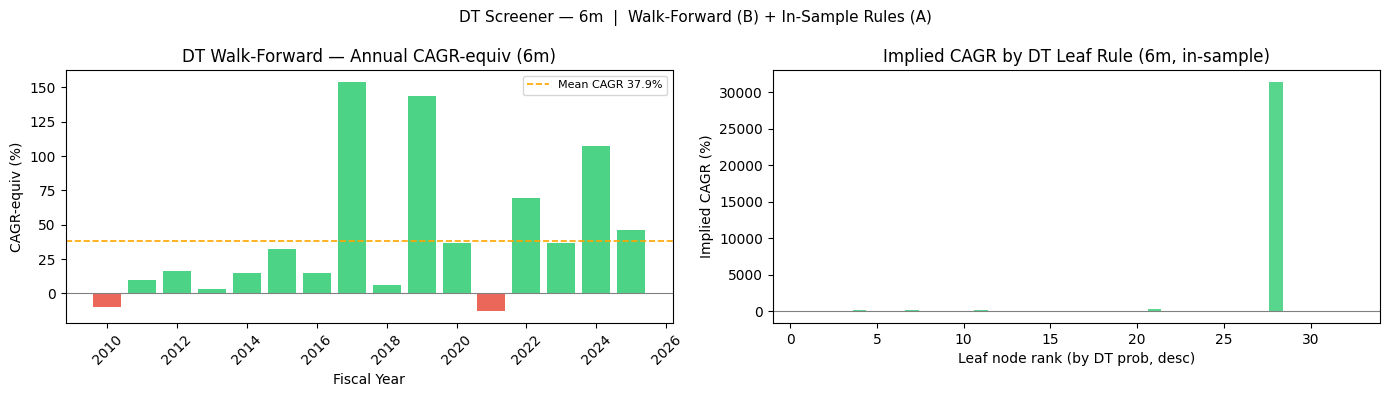

,N,ret_%,excess_%,train_n,CAGR_equiv_%
Year,,,,,
2010,100,-5.310000,1.330000,252,-10.338039
2011,100,4.780000,0.680000,922,9.788484
2012,100,7.880000,-2.640000,2537,16.380944
2013,100,1.680000,0.310000,4363,3.388224
2014,100,7.120000,10.290000,6250,14.746944
2015,100,14.980000,0.310000,8228,32.204004
2016,100,7.170000,1.770000,10520,14.854089
2017,100,59.410000,50.730000,12907,154.115481
2018,100,2.990000,3.640000,15429,6.069401



  DT Screener — horizon=1y  depth=5  top-100
── A: Per-Rule Performance (in-sample — full-history DT) ───────────


,leaf_id,samples,dt_prob,hit_rate_%,avg_ret_%,CAGR_%
1,58,40,0.975000,97.500000,61.010000,61.010000
2,24,31,0.645200,64.500000,35.220000,35.220000
3,59,32,0.625000,62.500000,35.640000,35.640000
4,62,667,0.593700,59.400000,28.580000,28.580000
5,13,152,0.532900,53.300000,50.390000,50.390000
6,43,373,0.530800,53.100000,37.360000,37.360000
7,61,2451,0.504300,50.400000,29.070000,29.070000
8,55,6706,0.500900,50.100000,15.490000,15.490000
9,6,146,0.472600,47.300000,45.570000,45.570000
10,52,4761,0.465900,46.600000,16.870000,16.870000


── B: Walk-Forward Backtest (1y, top-100, expanding window) ──
  Years            : 2010 – 2025  (16 periods)
  Implied CAGR     : 24.02%
  Excess vs bench  : 19.96%
  Hit rate         : 93.8%
  Sharpe (CAGR/vol): 1.02


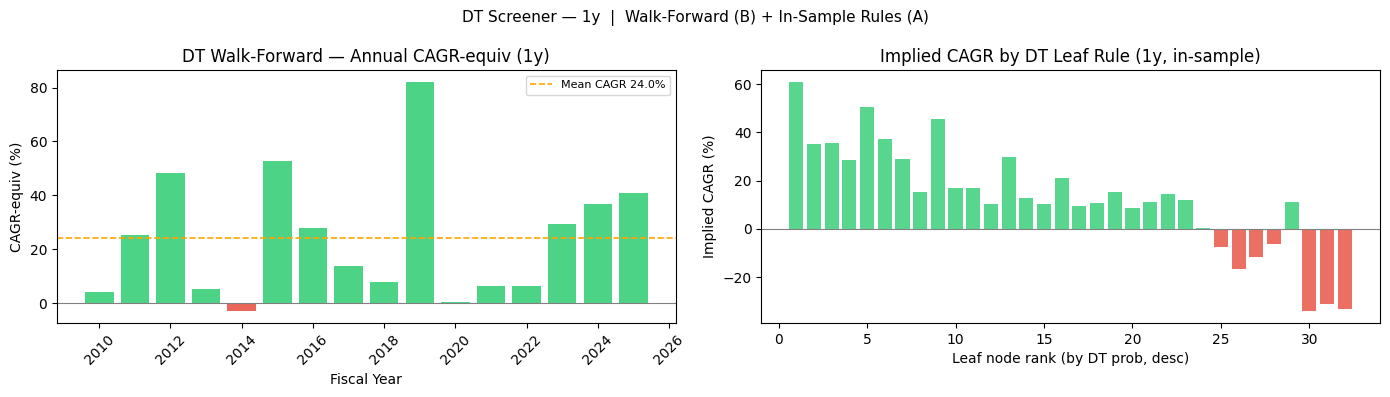

,N,ret_%,excess_%,train_n,CAGR_equiv_%
Year,,,,,
2010,100,4.120000,1.880000,252,4.120000
2011,100,25.100000,7.310000,922,25.100000
2012,100,48.290000,35.330000,2537,48.290000
2013,100,5.140000,-2.960000,4363,5.140000
2014,100,-3.080000,13.640000,6251,-3.080000
2015,100,52.800000,65.710000,8229,52.800000
2016,100,27.880000,15.150000,10520,27.880000
2017,100,13.950000,15.950000,12907,13.950000
2018,100,7.870000,50.900000,15426,7.870000



  DT Screener — horizon=2y  depth=5  top-100
── A: Per-Rule Performance (in-sample — full-history DT) ───────────


,leaf_id,samples,dt_prob,hit_rate_%,avg_ret_%,CAGR_%
1,7,49,1.000000,100.000000,120.470000,48.480000
2,6,57,0.789500,78.900000,66.500000,29.030000
3,32,71,0.662000,66.200000,365.560000,115.770000
4,47,98,0.612200,61.200000,190.630000,70.480000
5,11,801,0.603000,60.300000,78.190000,33.490000
6,42,378,0.595200,59.500000,143.450000,56.030000
7,5,33,0.515200,51.500000,104.600000,43.040000
8,10,1546,0.509700,51.000000,50.470000,22.670000
9,14,3344,0.507800,50.800000,31.500000,14.670000
10,51,116,0.482800,48.300000,204.760000,74.570000


── B: Walk-Forward Backtest (2y, top-100, expanding window) ──
  Years            : 2010 – 2024  (15 periods)
  Implied CAGR     : 23.34%
  Excess vs bench  : 12.45%
  Hit rate         : 100.0%
  Sharpe (CAGR/vol): 1.746


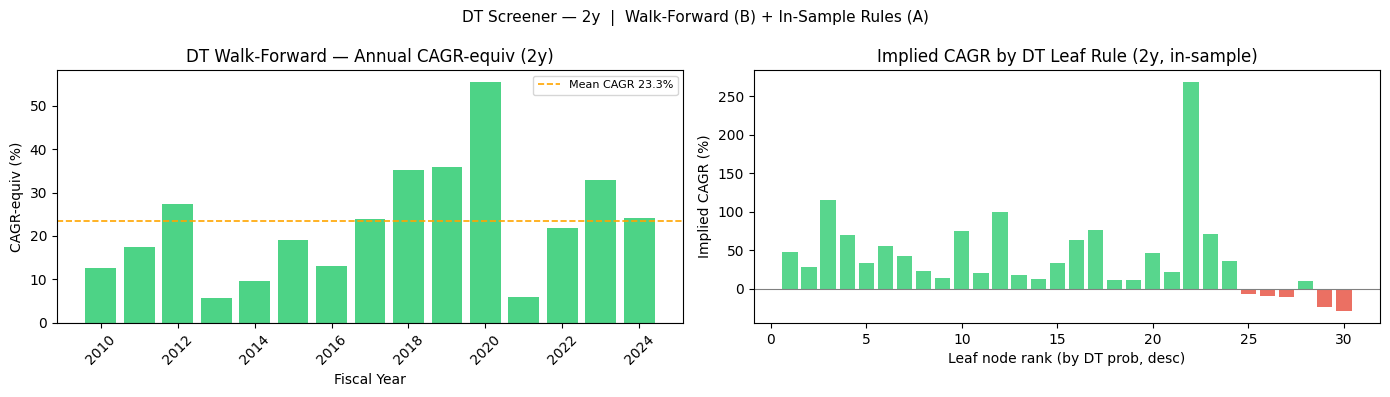

,N,ret_%,excess_%,train_n,CAGR_equiv_%
Year,,,,,
2010,100,26.860000,6.660000,252,12.632145
2011,100,38.000000,-4.870000,922,17.473401
2012,100,62.490000,23.510000,2537,27.471565
2013,100,11.590000,7.100000,4363,5.636168
2014,100,20.120000,3.830000,6251,9.599270
2015,100,41.820000,-0.720000,8229,19.088203
2016,100,28.080000,9.230000,10520,13.172435
2017,100,53.370000,51.160000,12904,23.842642
2018,100,82.540000,43.310000,15424,35.107365



  DT Screener — horizon=3y  depth=5  top-100
── A: Per-Rule Performance (in-sample — full-history DT) ───────────


,leaf_id,samples,dt_prob,hit_rate_%,avg_ret_%,CAGR_%
1,13,479,0.691000,69.100000,61.780000,17.390000
2,47,43,0.627900,62.800000,113.040000,28.670000
3,5,1358,0.572200,57.200000,110.220000,28.100000
4,12,877,0.561000,56.100000,65.330000,18.250000
5,15,1603,0.509000,50.900000,46.600000,13.600000
6,20,2191,0.485200,48.500000,65.140000,18.200000
7,36,202,0.485100,48.500000,79.510000,21.530000
8,8,5226,0.455000,45.500000,51.040000,14.740000
9,40,112,0.419600,42.000000,36.670000,10.970000
10,24,6611,0.409800,41.000000,38.200000,11.390000


── B: Walk-Forward Backtest (3y, top-100, expanding window) ──
  Years            : 2010 – 2023  (14 periods)
  Implied CAGR     : 19.67%
  Excess vs bench  : 49.58%
  Hit rate         : 100.0%
  Sharpe (CAGR/vol): 3.27


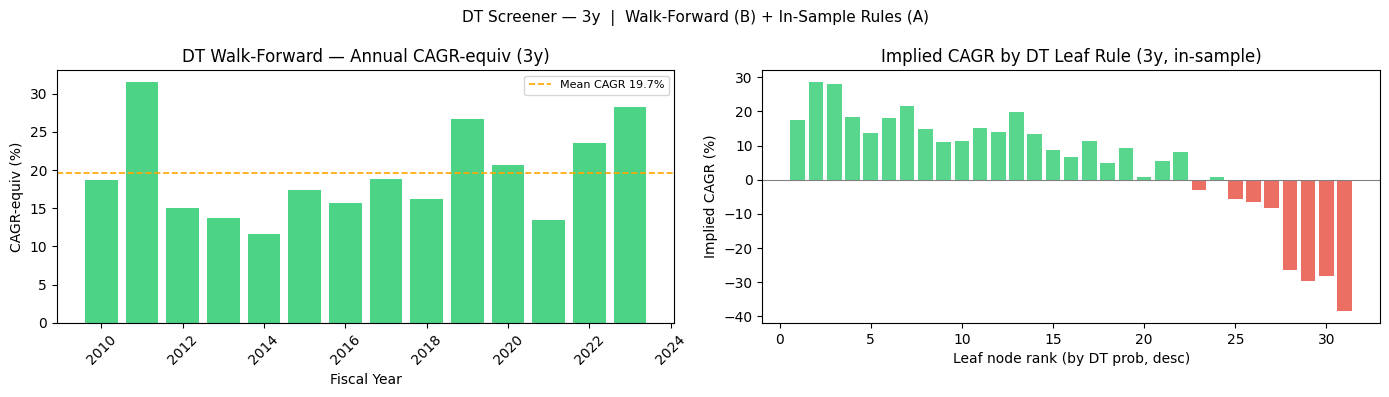

,N,ret_%,excess_%,train_n,CAGR_equiv_%
Year,,,,,
2010,100,67.350000,26.840000,252,18.724925
2011,100,127.280000,85.500000,922,31.478197
2012,100,52.300000,22.380000,2537,15.053535
2013,100,47.130000,19.450000,4363,13.736645
2014,100,39.340000,6.310000,6251,11.692823
2015,100,61.890000,17.100000,8229,17.419441
2016,100,54.660000,30.060000,10517,15.644771
2017,100,67.710000,36.080000,12902,18.809997
2018,100,56.980000,10.000000,15422,16.220153



  DT Screener — horizon=5y  depth=5  top-100
── A: Per-Rule Performance (in-sample — full-history DT) ───────────


,leaf_id,samples,dt_prob,hit_rate_%,avg_ret_%,CAGR_%
1,16,35,0.885700,88.600000,175.570000,22.470000
2,8,512,0.712900,71.300000,219.350000,26.140000
3,38,33,0.636400,63.600000,72.320000,11.500000
4,20,488,0.577900,57.800000,156.530000,20.730000
5,6,444,0.565300,56.500000,150.500000,20.160000
6,9,335,0.561200,56.100000,104.610000,15.400000
7,36,43,0.558100,55.800000,212.570000,25.600000
8,15,2207,0.511600,51.200000,86.170000,13.240000
9,12,1137,0.505700,50.600000,135.890000,18.730000
10,42,108,0.416700,41.700000,99.790000,14.850000


── B: Walk-Forward Backtest (5y, top-100, expanding window) ──
  Years            : 2010 – 2021  (12 periods)
  Implied CAGR     : 15.88%
  Excess vs bench  : 13.40%
  Hit rate         : 100.0%
  Sharpe (CAGR/vol): 3.599


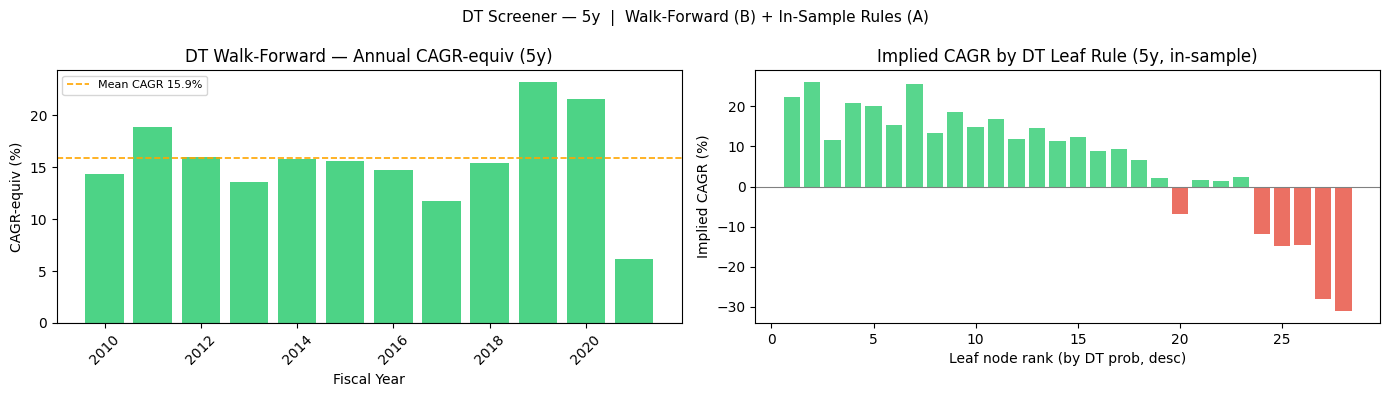

,N,ret_%,excess_%,train_n,CAGR_equiv_%
Year,,,,,
2010,100,95.130000,47.480000,252,14.304890
2011,100,137.860000,51.510000,922,18.922569
2012,100,109.560000,24.090000,2537,15.947577
2013,100,88.730000,51.340000,4363,13.545045
2014,100,107.790000,69.350000,6251,15.751047
2015,100,106.670000,73.080000,8228,15.625996
2016,100,98.570000,24.030000,10512,14.705100
2017,100,74.530000,28.560000,12889,11.782551
2018,100,104.580000,86.150000,15405,15.391185


In [37]:
import numpy as np

annual_dt_base = df_dt[df_dt['period_type'] == 'annual'].copy()
hor_years_map  = {'6m': 0.5, '1y': 1, '2y': 2, '3y': 3, '5y': 5}
WF_MIN_TRAIN_ROWS = 200  # min rows before walk-forward starts

for h in DT_HORIZONS:
    dt_feats_h   = dt_feats_by_h[h]
    X_tr         = X_train_by_h[h]   # full-history model — Part A only
    y_tr         = y_train_by_h[h]
    model_h      = dt_models[h]       # full-history model — Part A only
    target_col_h = f'beat_local_market_{h}'
    ret_col_h    = f'forward_return_{h}'
    exc_col_h    = f'excess_return_local_{h}'
    hor_years    = hor_years_map.get(h, 1)
    train_mask_h = df_dt[target_col_h].notna()

    print(f"\n{'='*65}")
    print(f"  DT Screener — horizon={h}  depth={DT_MAX_DEPTH}  top-{TOP_N_DT}")
    print(f"{'='*65}")

    # ── A: Per-rule (leaf-node) performance — in-sample rule inspection ──────
    train_rows_h = df_dt.loc[train_mask_h].copy()
    train_rows_h['leaf_id'] = model_h.apply(X_tr)
    train_rows_h['dt_prob'] = model_h.predict_proba(X_tr)[:, 1]

    leaf_perf_h = pd.DataFrame()
    if ret_col_h in train_rows_h.columns:
        leaf_perf_h = (
            train_rows_h[train_rows_h[ret_col_h].notna()]
            .groupby('leaf_id')
            .agg(
                n           = ('dt_prob', 'count'),
                hit_rate    = (target_col_h, 'mean'),
                avg_ret     = (ret_col_h, 'mean'),
                avg_dt_prob = ('dt_prob', 'mean'),
            )
            .reset_index()
        )
        leaf_perf_h['cagr_pct'] = ((1 + leaf_perf_h['avg_ret']) ** (1 / hor_years) - 1) * 100
        leaf_perf_h = leaf_perf_h.sort_values('avg_dt_prob', ascending=False).reset_index(drop=True)
        leaf_perf_h.index += 1
        leaf_perf_h['hit_rate']    = (leaf_perf_h['hit_rate'] * 100).round(1)
        leaf_perf_h['avg_ret']     = (leaf_perf_h['avg_ret'] * 100).round(2)
        leaf_perf_h['cagr_pct']    = leaf_perf_h['cagr_pct'].round(2)
        leaf_perf_h['avg_dt_prob'] = leaf_perf_h['avg_dt_prob'].round(4)
        lp_display = leaf_perf_h[['leaf_id', 'n', 'avg_dt_prob', 'hit_rate', 'avg_ret', 'cagr_pct']].rename(
            columns={'n': 'samples', 'avg_dt_prob': 'dt_prob',
                     'hit_rate': 'hit_rate_%', 'avg_ret': 'avg_ret_%', 'cagr_pct': 'CAGR_%'})
        print(f'── A: Per-Rule Performance (in-sample — full-history DT) ───────────')
        display(lp_display.style.background_gradient(subset=['CAGR_%'], cmap='RdYlGn'))
        print()

    # ── B: Walk-forward backtest — no look-ahead bias ─────────────────────────
    # Each year Y: train on fiscal_year < Y (expanding window), score year Y
    all_years = sorted(annual_dt_base['fiscal_year'].dropna().unique())
    bt_rows = []

    for yr in all_years:
        wf_mask = df_dt[target_col_h].notna() & (df_dt['fiscal_year'] < yr)
        if wf_mask.sum() < WF_MIN_TRAIN_ROWS:
            continue
        X_tr_wf = df_dt.loc[wf_mask, dt_feats_h].fillna(
                      df_dt.loc[wf_mask, dt_feats_h].median())
        y_tr_wf = df_dt.loc[wf_mask, target_col_h]
        if y_tr_wf.nunique() < 2:
            continue

        model_wf = DecisionTreeClassifier(
            max_depth=DT_MAX_DEPTH, min_samples_leaf=30, random_state=42)
        model_wf.fit(X_tr_wf, y_tr_wf)

        yr_df = annual_dt_base[annual_dt_base['fiscal_year'] == yr].copy()
        if len(yr_df) < 5:
            continue
        X_yr = yr_df[dt_feats_h].fillna(X_tr_wf.median())
        yr_df['dt_score_wf'] = model_wf.predict_proba(X_yr)[:, 1]

        yr_valid = yr_df[yr_df[ret_col_h].notna() & yr_df['dt_score_wf'].notna()]
        if len(yr_valid) < 5:
            continue

        top_yr = yr_valid.nlargest(min(TOP_N_DT, len(yr_valid)), 'dt_score_wf')
        bt_rows.append({
            'Year':     int(yr),
            'N':        len(top_yr),
            'ret_%':    round(top_yr[ret_col_h].mean() * 100, 2),
            'excess_%': round(top_yr[exc_col_h].mean() * 100, 2)
                        if exc_col_h in top_yr.columns else np.nan,
            'train_n':  int(wf_mask.sum()),
        })

    bt_df = pd.DataFrame(bt_rows)

    if not bt_df.empty and bt_df['ret_%'].notna().sum() >= 2:
        bt_df['CAGR_equiv_%'] = ((1 + bt_df['ret_%'] / 100) ** (1 / hor_years) - 1) * 100
        cagr_pct = ((1 + bt_df['ret_%'].mean() / 100) ** (1 / hor_years) - 1) * 100
        vol      = bt_df['CAGR_equiv_%'].std()
        sharpe   = round(cagr_pct / vol, 3) if vol > 0 else np.nan
        hit_pct  = round((bt_df['ret_%'] > 0).mean() * 100, 1)
        exc_cagr = ((1 + bt_df['excess_%'].mean() / 100) ** (1 / hor_years) - 1) * 100 \
                   if bt_df['excess_%'].notna().any() else np.nan

        print(f'── B: Walk-Forward Backtest ({h}, top-{TOP_N_DT}, expanding window) ──')
        print(f'  Years            : {bt_df["Year"].min()} – {bt_df["Year"].max()}  ({len(bt_df)} periods)')
        print(f'  Implied CAGR     : {cagr_pct:.2f}%')
        if not np.isnan(exc_cagr):
            print(f'  Excess vs bench  : {exc_cagr:.2f}%')
        print(f'  Hit rate         : {hit_pct}%')
        if not np.isnan(sharpe):
            print(f'  Sharpe (CAGR/vol): {sharpe}')

        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        ax = axes[0]
        bar_colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in bt_df['CAGR_equiv_%']]
        ax.bar(bt_df['Year'], bt_df['CAGR_equiv_%'], color=bar_colors, alpha=0.85, edgecolor='none')
        ax.axhline(0, color='gray', linewidth=0.8)
        ax.axhline(cagr_pct, color='orange', linestyle='--', linewidth=1.2,
                   label=f'Mean CAGR {cagr_pct:.1f}%')
        ax.set_xlabel('Fiscal Year')
        ax.set_ylabel('CAGR-equiv (%)')
        ax.set_title(f'DT Walk-Forward — Annual CAGR-equiv ({h})')
        ax.legend(fontsize=8)
        ax.tick_params(axis='x', rotation=45)

        ax = axes[1]
        if not leaf_perf_h.empty:
            lc = ['#2ecc71' if v > 0 else '#e74c3c' for v in leaf_perf_h['cagr_pct']]
            ax.bar(leaf_perf_h.index, leaf_perf_h['cagr_pct'], color=lc, alpha=0.8, edgecolor='none')
            ax.axhline(0, color='gray', linewidth=0.8)
            ax.set_xlabel('Leaf node rank (by DT prob, desc)')
            ax.set_ylabel('Implied CAGR (%)')
            ax.set_title(f'Implied CAGR by DT Leaf Rule ({h}, in-sample)')
        else:
            ax.text(0.5, 0.5, f'{ret_col_h} not available', ha='center', va='center',
                    transform=ax.transAxes)

        plt.suptitle(f'DT Screener — {h}  |  Walk-Forward (B) + In-Sample Rules (A)', fontsize=11)
        plt.tight_layout()
        plt.show()

        display(
            bt_df.set_index('Year')
                 .style.background_gradient(subset=['CAGR_equiv_%'], cmap='RdYlGn')
        )
    else:
        print(f'Insufficient backtest data ({len(bt_df)} years with valid returns).')
